# Swat Flood Prediction — Model Training Notebook
## Section 1: Setup

This section mounts Google Drive, installs required libraries, imports them, and loads the dataset CSV for a first look.

### 1. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 2. Install Libraries
xgboost, lightgbm, and shap are not pre-installed in Colab by default.

In [ ]:
!pip install xgboost lightgbm shap --quiet

### 3. Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GroupKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_curve,
    average_precision_score, roc_auc_score, roc_curve, f1_score
)

import xgboost as xgb
from xgboost import XGBClassifier

import lightgbm as lgb
from lightgbm import LGBMClassifier

import shap

import joblib

print("All libraries imported successfully.")

All libraries imported successfully.


### 4. Load CSV from Drive

Update `CSV_PATH` below to match your file's exact location in Google Drive before running.

In [ ]:
CSV_PATH = '/content/drive/MyDrive/fyp dataset/Swat_District_ML_Flood_Dataset_SAR_Final.csv'

df = pd.read_csv(CSV_PATH)

print("Shape (rows, columns):", df.shape)
print()
print("Column data types:")
print(df.dtypes)
print()
print("Sample rows:")
df.tail(10)

Shape (rows, columns): (55194, 36)

Column data types:
system:index          int64
annual_rain_mean    float64
drainage_density    float64
elevation           float64
flood                 int64
hand                float64
landcover             int64
latitude            float64
longitude           float64
ndvi                float64
rain_2015           float64
rain_2016           float64
rain_2017           float64
rain_2018           float64
rain_2019           float64
rain_2020           float64
rain_2021           float64
rain_2022           float64
rain_2023           float64
rain_2024           float64
rain_apr            float64
rain_aug            float64
rain_dec            float64
rain_feb            float64
rain_jan            float64
rain_jul            float64
rain_jun            float64
rain_mar            float64
rain_may            float64
rain_nov            float64
rain_oct            float64
rain_sep            float64
slope               float64
stream_proximity    f

,system:index,annual_rain_mean,drainage_density,elevation,flood,hand,landcover,latitude,longitude,ndvi,...,rain_jun,rain_mar,rain_may,rain_nov,rain_oct,rain_sep,slope,stream_proximity,upstream_area,.geo
55184,55184,562.224057,45.628357,3424.8460,1,0.000000,60,35.352704,72.449173,-0.048710,...,22.936106,108.223892,45.370458,37.523656,18.057090,40.263077,2.759192,179.840574,27.008802,"{""type"":""MultiPoint"",""coordinates"":[]}"
55185,55185,857.904448,56.777658,903.0000,1,2.500000,80,34.792425,72.339758,-0.270516,...,30.737047,125.164266,49.959734,39.551161,49.367015,80.725495,0.564682,105.938331,0.007043,"{""type"":""MultiPoint"",""coordinates"":[]}"
55186,55186,839.391195,74.736842,1120.8780,1,0.599976,80,34.964632,72.459144,-0.064593,...,47.099602,110.470927,63.034921,29.718816,32.444501,72.372663,0.789037,128.665082,0.007028,"{""type"":""MultiPoint"",""coordinates"":[]}"
55187,55187,942.461947,61.904762,1171.3282,1,1.800049,80,35.014758,72.464803,-0.393754,...,60.160966,115.712950,85.406613,27.687331,32.385876,92.326432,3.018632,7.739003,0.014048,"{""type"":""MultiPoint"",""coordinates"":[]}"
55188,55188,562.224057,32.567132,3673.8804,1,0.000000,80,35.367257,72.415216,-0.043301,...,22.936106,108.223892,45.370458,37.523656,18.057090,40.263077,13.481660,45.205837,8.828136,"{""type"":""MultiPoint"",""coordinates"":[]}"
55189,55189,833.614877,71.851056,1066.1042,1,0.000000,80,34.915314,72.434350,-0.442476,...,35.379330,116.155490,51.698696,42.301443,39.425959,90.444872,1.000363,128.084766,3681.005600,"{""type"":""MultiPoint"",""coordinates"":[]}"
55190,55190,441.869205,64.303616,2862.0180,1,0.900146,100,35.705742,72.655066,0.300048,...,22.014739,70.002697,38.032990,24.392228,26.731005,65.070978,1.586415,119.160117,0.006965,"{""type"":""MultiPoint"",""coordinates"":[]}"
55191,55191,624.987031,56.842105,1661.1968,1,6.599976,80,35.335456,72.612486,0.261877,...,35.798268,106.686263,44.141555,24.954214,15.548098,55.470362,14.123676,163.479984,0.055971,"{""type"":""MultiPoint"",""coordinates"":[]}"
55192,55192,839.459866,67.447189,1026.1393,1,0.000000,80,34.876507,72.429499,-0.026880,...,37.023860,116.878018,52.990922,40.289295,40.521209,91.556007,1.057837,208.505343,3714.774400,"{""type"":""MultiPoint"",""coordinates"":[]}"
55193,55193,698.738451,59.541711,1515.3258,1,0.000000,80,35.264040,72.598473,-0.306961,...,35.613531,113.042349,54.967108,29.915320,15.917409,60.512186,10.468301,38.427988,2480.109900,"{""type"":""MultiPoint"",""coordinates"":[]}"


## Section 2: Data Cleaning

Checks missing values, verifies there are no duplicate coordinates, sanity-checks physically impossible values, and confirms the class balance before any modeling begins.

### 5. Missing Values Check

In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0]

if len(missing) == 0:
    print("No missing values found in any column.")
else:
    print("Missing values per column:")
    print(missing)
    print()
    before = len(df)
    df = df.dropna()
    print(f"Dropped {before - len(df)} rows containing missing values.")
    print("New shape:", df.shape)

No missing values found in any column.


### 6. Duplicate Rows Check (lat/long level)

A prior manual check on this dataset confirmed 0 duplicate coordinate pairs. This cell re-verifies that programmatically so the notebook is self-contained and doesn't rely on that earlier check.

In [ ]:
dupe_coords = df.duplicated(subset=['latitude', 'longitude']).sum()
print(f"Duplicate latitude/longitude pairs: {dupe_coords}")

if dupe_coords > 0:
    before = len(df)
    df = df.drop_duplicates(subset=['latitude', 'longitude'])
    print(f"Dropped {before - len(df)} duplicate-coordinate rows.")
    print("New shape:", df.shape)
else:
    print("Confirmed: every row is a unique coordinate. No action needed.")

Duplicate latitude/longitude pairs: 0
Confirmed: every row is a unique coordinate. No action needed.


### 7. Sanity-Bound Checks

Flags physically impossible values that would indicate a data-extraction problem (e.g. negative elevation, NDVI outside its valid [-1, 1] range, slope outside 0-90 degrees). This does not assume any specific column exists beyond what the dataset defines - it checks each one only if present.

In [ ]:
issues_found = False

# Elevation should not be negative in this region
if 'elevation' in df.columns:
    bad = (df['elevation'] < 0).sum()
    if bad > 0:
        issues_found = True
        print(f"[elevation] {bad} rows with negative elevation")

# Slope must be within 0-90 degrees
if 'slope' in df.columns:
    bad = ((df['slope'] < 0) | (df['slope'] > 90)).sum()
    if bad > 0:
        issues_found = True
        print(f"[slope] {bad} rows outside valid 0-90 degree range")

# NDVI must be within -1.0 to +1.0
if 'ndvi' in df.columns:
    bad = ((df['ndvi'] < -1.0) | (df['ndvi'] > 1.0)).sum()
    if bad > 0:
        issues_found = True
        print(f"[ndvi] {bad} rows outside valid -1.0 to +1.0 range")

# Stream proximity, drainage density, upstream area, HAND should not be negative
for col in ['stream_proximity', 'drainage_density', 'upstream_area', 'hand']:
    if col in df.columns:
        bad = (df[col] < 0).sum()
        if bad > 0:
            issues_found = True
            print(f"[{col}] {bad} rows with negative values")

# Rainfall columns should not be negative
rain_cols = [c for c in df.columns if c.startswith('rain_') or c == 'annual_rain_mean']
for col in rain_cols:
    bad = (df[col] < 0).sum()
    if bad > 0:
        issues_found = True
        print(f"[{col}] {bad} rows with negative rainfall")

# Latitude/longitude should fall within Swat district's approximate bounds
if 'latitude' in df.columns and 'longitude' in df.columns:
    bad = (
        (df['latitude'] < 34.0) | (df['latitude'] > 36.0) |
        (df['longitude'] < 71.5) | (df['longitude'] > 73.0)
    ).sum()
    if bad > 0:
        issues_found = True
        print(f"[latitude/longitude] {bad} rows fall outside Swat district's approximate bounding box")

if not issues_found:
    print("No sanity-bound violations found. All values are within physically valid ranges.")

No sanity-bound violations found. All values are within physically valid ranges.


### 8. Class Balance Check

Prints the flood(1) vs non-flood(0) counts and their percentage share. This dataset is expected to be imbalanced (roughly 3-8% flood-positive), which will be handled explicitly during model training (class weighting, PR-AUC as the primary metric) rather than ignored.

Class counts:
  Non-flood (0): 50000  (90.59%)
  Flood (1): 5194  (9.41%)

Total rows: 55194
Imbalance ratio (non-flood : flood) = 9.6 : 1


/tmp/ipykernel_471/1132421687.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Non-flood (0)', 'Flood (1)'], y=flood_counts.values, palette=['steelblue', 'indianred'])


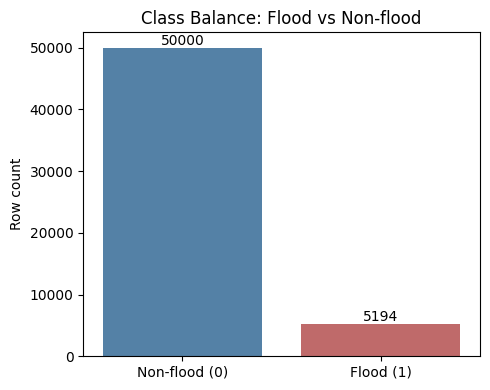

In [ ]:
flood_counts = df['flood'].value_counts().sort_index()
flood_pct = df['flood'].value_counts(normalize=True).sort_index() * 100

print("Class counts:")
for cls in flood_counts.index:
    label = "Non-flood (0)" if cls == 0 else "Flood (1)"
    print(f"  {label}: {flood_counts[cls]}  ({flood_pct[cls]:.2f}%)")

print()
print(f"Total rows: {len(df)}")
print(f"Imbalance ratio (non-flood : flood) = {flood_counts[0] / flood_counts[1]:.1f} : 1")

plt.figure(figsize=(5, 4))
sns.barplot(x=['Non-flood (0)', 'Flood (1)'], y=flood_counts.values, palette=['steelblue', 'indianred'])
plt.ylabel('Row count')
plt.title('Class Balance: Flood vs Non-flood')
for i, v in enumerate(flood_counts.values):
    plt.text(i, v, f'{v}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

## Section 3: Exploratory Data Analysis (EDA)

Visual and statistical checks to understand feature relationships, multicollinearity, and whether the flood label behaves sensibly across terrain, rainfall, geography, and land cover before any model is trained.

### 9. Correlation Heatmap (All Numeric Features)

`rain_2015`...`rain_2024` are expected to be highly correlated with each other and with `annual_rain_mean`, since they represent overlapping information (yearly totals vs. their own average). This is flagged here, not silently ignored - it matters when selecting final training features.

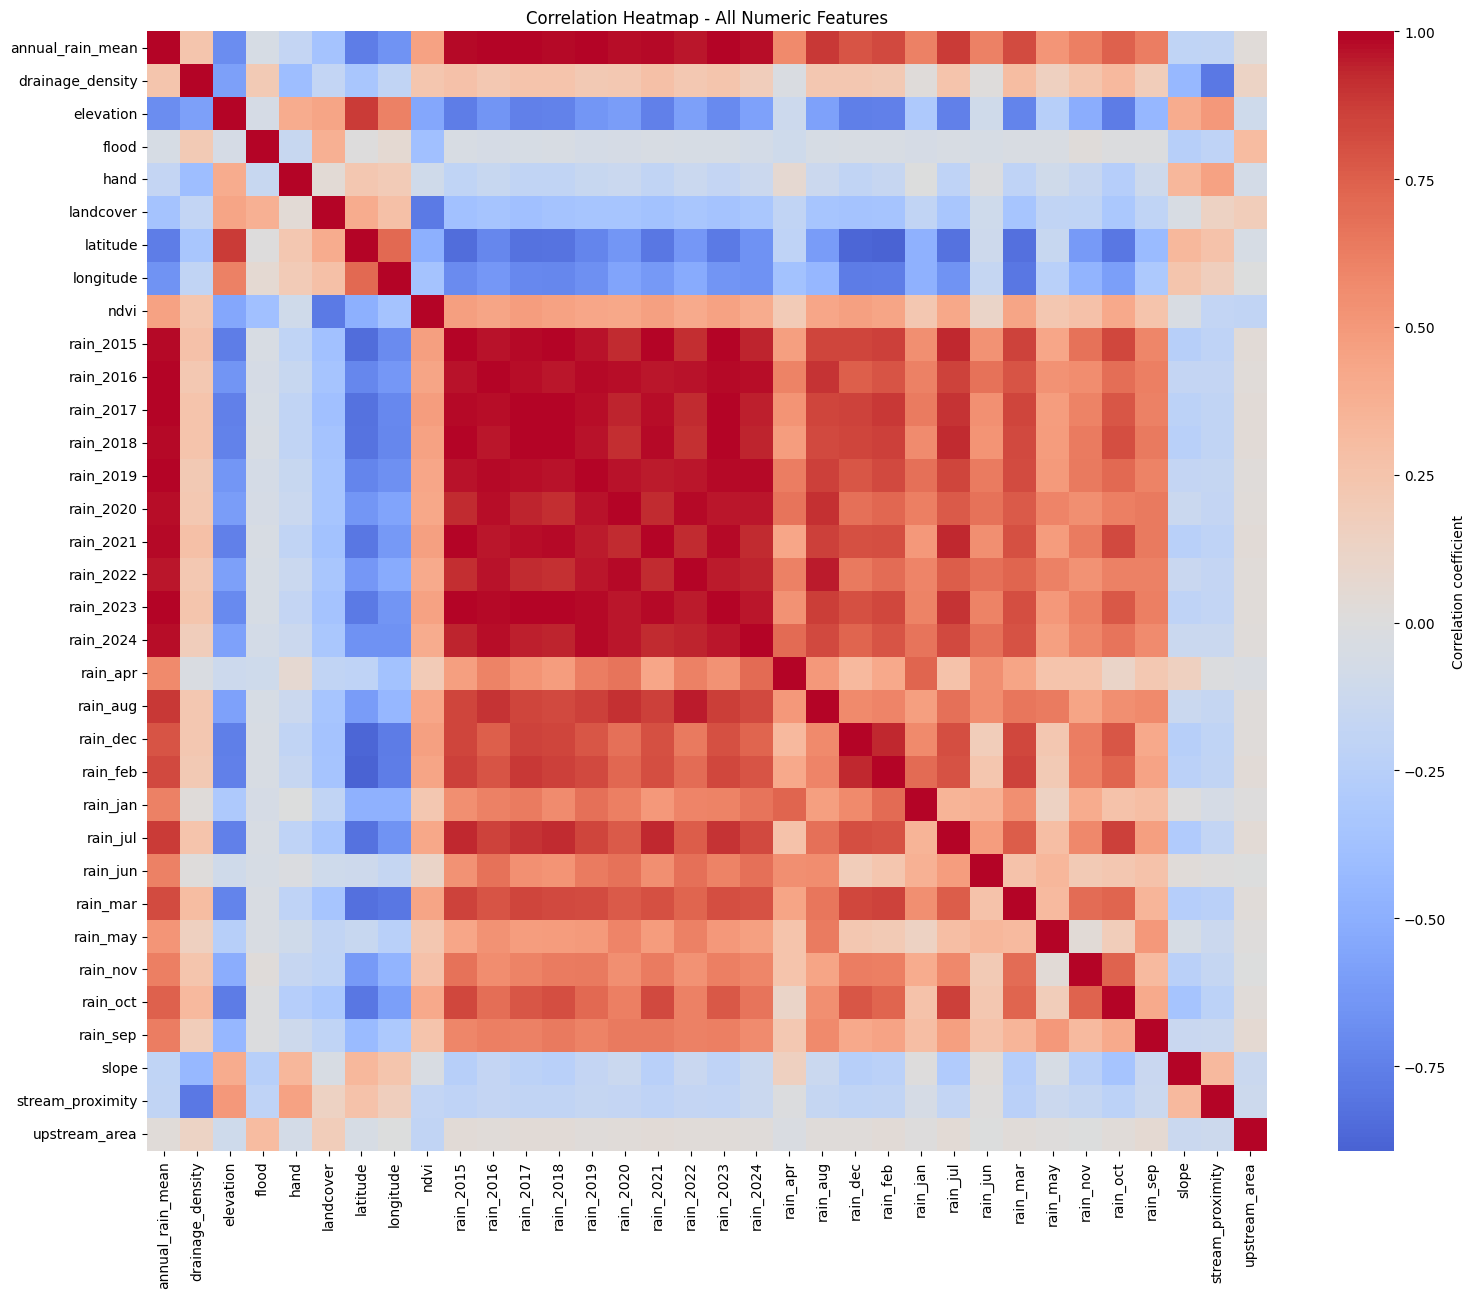

Correlation of yearly rainfall columns with annual_rain_mean:
annual_rain_mean    1.000000
rain_2023           0.996257
rain_2016           0.992196
rain_2019           0.991473
rain_2017           0.986899
rain_2015           0.983641
rain_2018           0.981416
rain_2021           0.979572
rain_2024           0.973302
rain_2020           0.972240
rain_2022           0.963027
Name: annual_rain_mean, dtype: float64

Rainfall column pairs with |correlation| > 0.8: 55
  rain_2015 <-> rain_2016: 0.966
  rain_2015 <-> rain_2017: 0.985
  rain_2015 <-> rain_2018: 0.987
  rain_2015 <-> rain_2019: 0.966
  rain_2015 <-> rain_2020: 0.922
  rain_2015 <-> rain_2021: 0.987
  rain_2015 <-> rain_2022: 0.914
  rain_2015 <-> rain_2023: 0.986
  rain_2015 <-> rain_2024: 0.938
  rain_2015 <-> annual_rain_mean: 0.984
  rain_2016 <-> rain_2017: 0.972
  rain_2016 <-> rain_2018: 0.962
  rain_2016 <-> rain_2019: 0.985
  rain_2016 <-> rain_2020: 0.975
  rain_2016 <-> rain_2021: 0.961
  rain_2016 <-> rain_2022:

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Drop non-feature numeric columns if present (e.g. an index column from GEE export)
numeric_cols = [c for c in numeric_cols if c not in ['system:index']]

corr = df[numeric_cols].corr()

plt.figure(figsize=(16, 13))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, square=True,
            cbar_kws={'label': 'Correlation coefficient'})
plt.title('Correlation Heatmap - All Numeric Features')
plt.tight_layout()
plt.show()

# Explicitly flag high correlations among the rainfall columns
rain_year_cols = [c for c in df.columns if c.startswith('rain_20')]
rain_corr = df[rain_year_cols + ['annual_rain_mean']].corr()

print("Correlation of yearly rainfall columns with annual_rain_mean:")
print(rain_corr['annual_rain_mean'].sort_values(ascending=False))

high_corr_pairs = []
cols = rain_corr.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        val = rain_corr.iloc[i, j]
        if abs(val) > 0.8:
            high_corr_pairs.append((cols[i], cols[j], round(val, 3)))

print()
print(f"Rainfall column pairs with |correlation| > 0.8: {len(high_corr_pairs)}")
for pair in high_corr_pairs:
    print(f"  {pair[0]} <-> {pair[1]}: {pair[2]}")

### 10. Boxplots: Key Features Split by Flood Label

Compares the distribution of core terrain and rainfall features between flood(1) and non-flood(0) points. A useful/discriminative feature should show a visibly different distribution between the two classes.

/tmp/ipykernel_471/3243475935.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='flood', y=feature, ax=ax, palette=['steelblue', 'indianred'])
/tmp/ipykernel_471/3243475935.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Non-flood (0)', 'Flood (1)'])
/tmp/ipykernel_471/3243475935.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='flood', y=feature, ax=ax, palette=['steelblue', 'indianred'])
/tmp/ipykernel_471/3243475935.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a

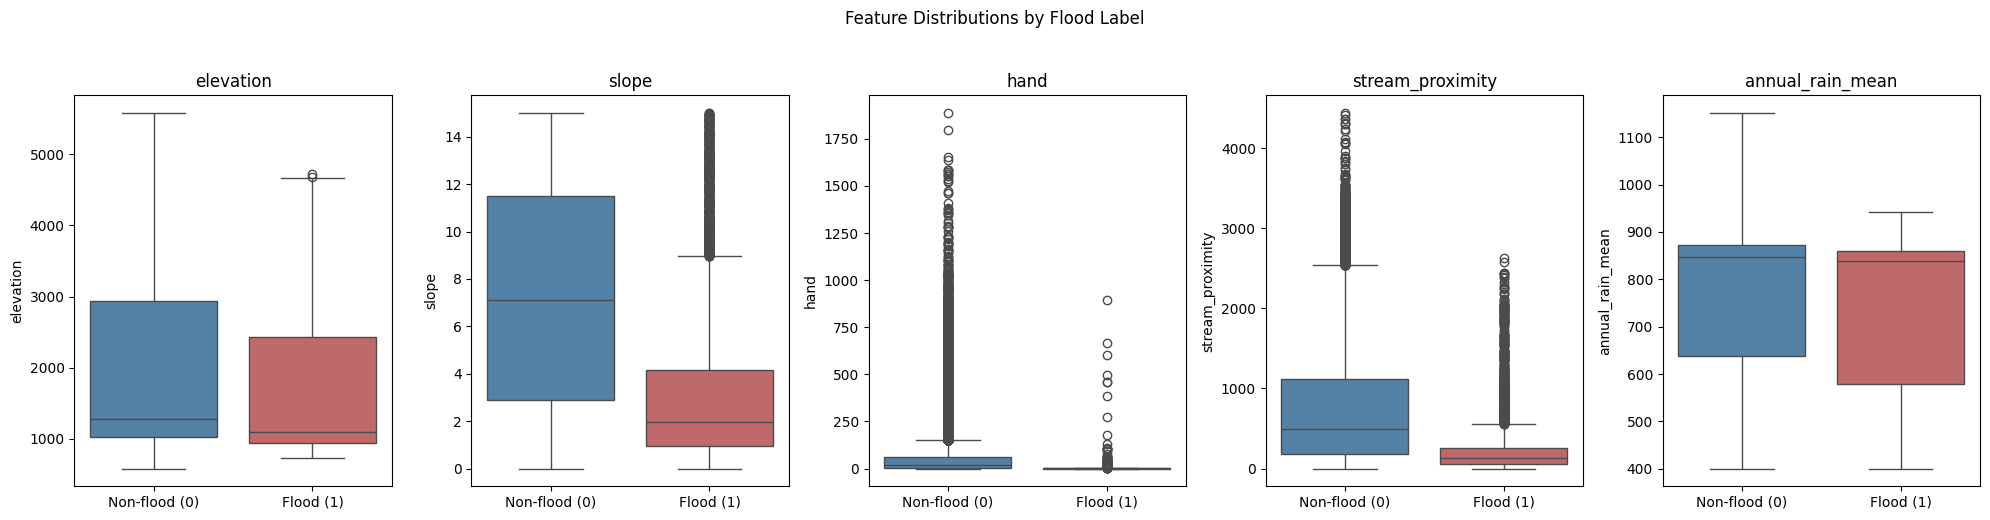

In [ ]:
key_features = ['elevation', 'slope', 'hand', 'stream_proximity', 'annual_rain_mean']
key_features = [f for f in key_features if f in df.columns]

fig, axes = plt.subplots(1, len(key_features), figsize=(4 * len(key_features), 5))
if len(key_features) == 1:
    axes = [axes]

for ax, feature in zip(axes, key_features):
    sns.boxplot(data=df, x='flood', y=feature, ax=ax, palette=['steelblue', 'indianred'])
    ax.set_xticklabels(['Non-flood (0)', 'Flood (1)'])
    ax.set_title(feature)
    ax.set_xlabel('')

plt.suptitle('Feature Distributions by Flood Label', y=1.03)
plt.tight_layout()
plt.show()

### 11. Geographic Scatter Plot (Flood Points on the Map)

Plots every point by its longitude/latitude, colored by flood label. This is a visual sanity check: flood(1) points should cluster near known river valleys and settlements (Kalam, Bahrain, Madyan, Mingora), not scattered randomly or concentrated in high-mountain areas.

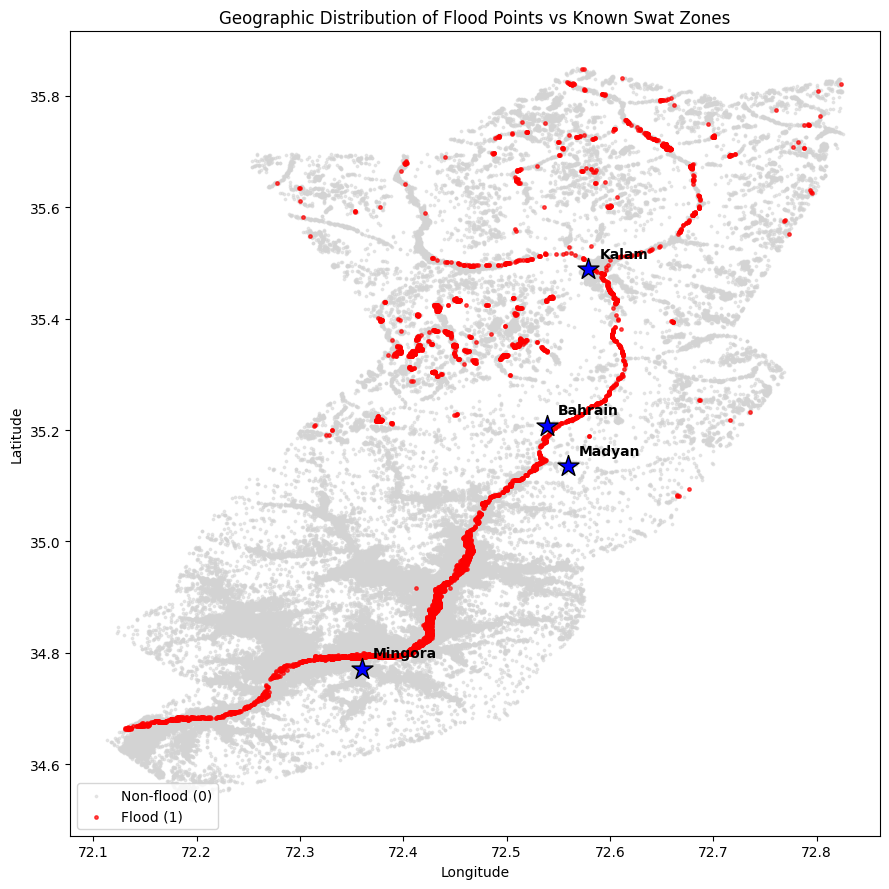

Visual check: confirm the red (flood=1) points concentrate near the blue star markers
(known river-valley settlements), not scattered across high-mountain areas.


In [ ]:
# Approximate reference coordinates for known Swat zones, for visual orientation only
reference_zones = {
    'Kalam':   (35.4890, 72.5790),
    'Bahrain': (35.2080, 72.5390),
    'Madyan':  (35.1350, 72.5590),
    'Mingora': (34.7720, 72.3600),
}

plt.figure(figsize=(9, 9))
plt.scatter(df.loc[df['flood'] == 0, 'longitude'], df.loc[df['flood'] == 0, 'latitude'],
            s=3, c='lightgray', label='Non-flood (0)', alpha=0.5)
plt.scatter(df.loc[df['flood'] == 1, 'longitude'], df.loc[df['flood'] == 1, 'latitude'],
            s=6, c='red', label='Flood (1)', alpha=0.7)

for name, (lat, lon) in reference_zones.items():
    plt.scatter(lon, lat, marker='*', s=250, c='blue', edgecolor='black', zorder=5)
    plt.annotate(name, (lon, lat), textcoords="offset points", xytext=(8, 8), fontsize=10, weight='bold')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographic Distribution of Flood Points vs Known Swat Zones')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

print("Visual check: confirm the red (flood=1) points concentrate near the blue star markers")
print("(known river-valley settlements), not scattered across high-mountain areas.")

### 12. Landcover Distribution — Flood vs Non-flood

Landcover class distribution within each flood/non-flood group:
           Non-flood (%)  Flood (%)
landcover                          
80             34.945904  65.054096
60             94.797688   5.202312
100            94.882580   5.117420
30             96.755892   3.244108
40             98.753743   1.246257
50             99.543639   0.456361
20             99.836066   0.163934
70             99.906774   0.093226
10             99.909107   0.090893


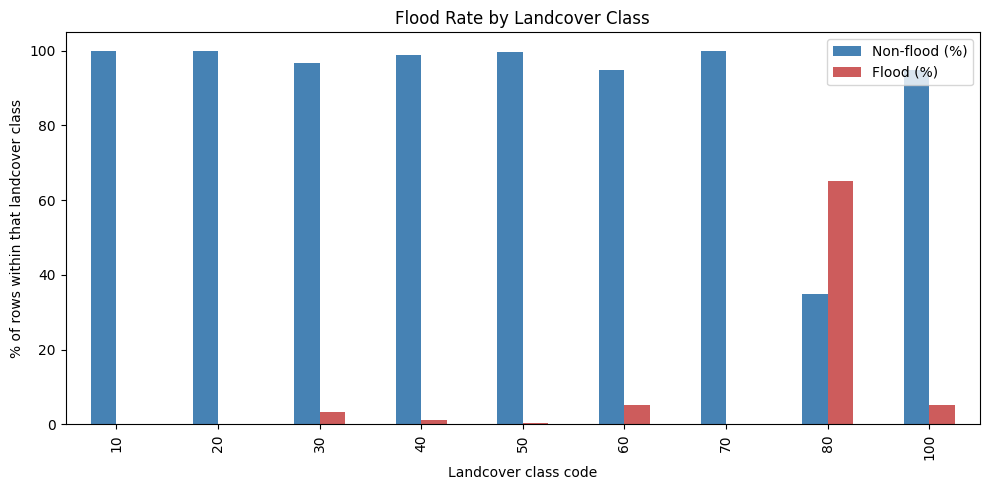

In [ ]:
landcover_ct = pd.crosstab(df['landcover'], df['flood'], normalize='index') * 100
landcover_ct.columns = ['Non-flood (%)', 'Flood (%)']

print("Landcover class distribution within each flood/non-flood group:")
print(landcover_ct.sort_values('Flood (%)', ascending=False))

landcover_ct.plot(kind='bar', figsize=(10, 5), color=['steelblue', 'indianred'])
plt.ylabel('% of rows within that landcover class')
plt.xlabel('Landcover class code')
plt.title('Flood Rate by Landcover Class')
plt.legend(title='')
plt.tight_layout()
plt.show()

### 13. Class Imbalance Visualization (Pie Chart)

Section 2 already showed the raw counts as a bar chart. This pie chart complements it by making the proportional imbalance visually immediate — useful for the FYP report/slides.

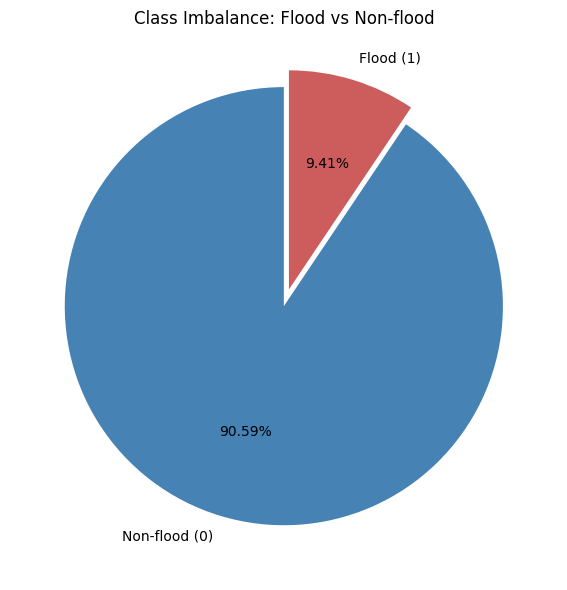

In [ ]:
flood_counts = df['flood'].value_counts().sort_index()

plt.figure(figsize=(6, 6))
plt.pie(
    flood_counts.values,
    labels=['Non-flood (0)', 'Flood (1)'],
    autopct='%1.2f%%',
    colors=['steelblue', 'indianred'],
    startangle=90,
    explode=(0, 0.08)
)
plt.title('Class Imbalance: Flood vs Non-flood')
plt.tight_layout()
plt.show()

## Section 4: Feature Engineering

Encodes the categorical landcover column, builds a small set of derived features that summarize the raw yearly rainfall columns more efficiently, addresses the multicollinearity flagged in Section 3, and finalizes the exact feature list that will be used for training.

### 14. Encode `landcover` (Label Encoding)

`landcover` holds ESA WorldCover class codes - already numeric, but treated as categorical since the codes represent distinct classes, not a continuous scale. Label Encoding is used (not One-Hot) since tree-based models (Random Forest, XGBoost, LightGBM) handle label-encoded categoricals natively and splitting on a handful of classes doesn't need one-hot expansion. The encoder is saved so the exact same mapping can be reapplied at inference time.

In [ ]:
landcover_encoder = LabelEncoder()
df['landcover_encoded'] = landcover_encoder.fit_transform(df['landcover'].astype(str))

print("Landcover classes found and their encoded values:")
for original, encoded in zip(landcover_encoder.classes_, landcover_encoder.transform(landcover_encoder.classes_)):
    print(f"  {original}  ->  {encoded}")

# Save the encoder now so it's not forgotten later - it must be reused
# identically at inference time (real-time prediction) for the mapping to
# stay consistent.
joblib.dump(landcover_encoder, '/content/drive/MyDrive/swat_landcover_encoder.joblib')
print()
print("Encoder saved to Drive: swat_landcover_encoder.joblib")

Landcover classes found and their encoded values:
  10  ->  0
  100  ->  1
  20  ->  2
  30  ->  3
  40  ->  4
  50  ->  5
  60  ->  6
  70  ->  7
  80  ->  8

Encoder saved to Drive: swat_landcover_encoder.joblib


### 15. Derived Features

Three engineered features that compress information from the raw yearly rainfall columns and add a terrain-interaction term:

- **`rainfall_std`** — standard deviation across `rain_2015`...`rain_2024`. Captures how *variable/unpredictable* a location's rainfall history is, which plain averages hide.
- **`rainfall_max_anomaly`** — the wettest year on record divided by the 10-year mean. A ratio close to 1 means rainfall is consistent year to year; a high ratio means this location has experienced extreme spikes relative to its own normal - directly related to how the flood label itself was constructed.
- **`terrain_ruggedness`** — `slope × elevation`, a simple interaction term. High elevation combined with steep slope behaves differently (runoff-wise) than either factor alone.

In [ ]:
rain_year_cols = [c for c in df.columns if c.startswith('rain_20')]

df['rainfall_std'] = df[rain_year_cols].std(axis=1)
df['rainfall_max_anomaly'] = df[rain_year_cols].max(axis=1) / df['annual_rain_mean']
df['terrain_ruggedness'] = df['slope'] * df['elevation']

print("Derived features created:")
print(df[['rainfall_std', 'rainfall_max_anomaly', 'terrain_ruggedness']].describe())

Derived features created:
       rainfall_std  rainfall_max_anomaly  terrain_ruggedness
count  55194.000000          55194.000000        55194.000000
mean     120.194054              1.259364        15711.930782
std       23.316708              0.033023        16362.382926
min       57.770229              1.152105            0.000000
25%      104.134695              1.235541         2795.988238
50%      126.674200              1.255901         9968.214492
75%      133.112195              1.277508        22594.257902
max      184.548325              1.384996        77583.577914


### 16. Handle Multicollinear Rainfall Columns

Section 3's correlation heatmap flagged `rain_2015`...`rain_2024` as highly correlated with `annual_rain_mean` and with each other - expected, since they're overlapping summaries of the same underlying rainfall record. Keeping all of them as separate features adds redundant, highly-correlated inputs without adding much new information, and can destabilize feature-importance interpretation (correlated features "split" importance between them).

**Decision:** drop the 10 raw yearly columns (`rain_2015`...`rain_2024`) from the training feature set, and rely on:
- `annual_rain_mean` (overall baseline)
- `rain_jan`...`rain_dec` (seasonal baseline - not dropped, since monthly patterns aren't redundant with the annual mean)
- `rainfall_std` and `rainfall_max_anomaly` (the engineered features from Step 15, which already summarize what the raw yearly columns contained)

The raw yearly columns are **not deleted from `df`** - only excluded from the modeling feature list - so they remain available if you want to re-run this comparison later.

In [ ]:
DROP_RAW_YEARLY_RAIN = True  # toggle this to False to keep rain_2015...rain_2024 as features instead

print(f"Dropping raw yearly rainfall columns from feature set: {DROP_RAW_YEARLY_RAIN}")
print(f"Columns affected: {rain_year_cols}")
print()
print("These remain in df (untouched) - they are only excluded from the")
print("feature list built in Step 17 below, not deleted from the dataset.")

Dropping raw yearly rainfall columns from feature set: True
Columns affected: ['rain_2015', 'rain_2016', 'rain_2017', 'rain_2018', 'rain_2019', 'rain_2020', 'rain_2021', 'rain_2022', 'rain_2023', 'rain_2024']

These remain in df (untouched) - they are only excluded from the
feature list built in Step 17 below, not deleted from the dataset.


### 17. Final Feature List Definition

Assembles the exact list of columns that will be used to train the model, based on all decisions made above.

In [ ]:
base_features = [
    'elevation', 'slope',
    'stream_proximity', 'drainage_density', 'upstream_area', 'hand',
    'landcover_encoded', 'ndvi',
    'annual_rain_mean',
    'rain_jan', 'rain_feb', 'rain_mar', 'rain_apr', 'rain_may', 'rain_jun',
    'rain_jul', 'rain_aug', 'rain_sep', 'rain_oct', 'rain_nov', 'rain_dec',
    'longitude', 'latitude'
]

engineered_features = ['rainfall_std', 'rainfall_max_anomaly', 'terrain_ruggedness']

if not DROP_RAW_YEARLY_RAIN:
    base_features += rain_year_cols

feature_cols = [c for c in (base_features + engineered_features) if c in df.columns]

print(f"Final feature count: {len(feature_cols)}")
print()
print("Final feature list:")
for f in feature_cols:
    print(f"  - {f}")

# Save the feature list now so Section 5 onward, and inference later, use
# exactly this set.
joblib.dump(feature_cols, '/content/drive/MyDrive/swat_feature_columns.joblib')
print()
print("Feature list saved to Drive: swat_feature_columns.joblib")

Final feature count: 26

Final feature list:
  - elevation
  - slope
  - stream_proximity
  - drainage_density
  - upstream_area
  - hand
  - landcover_encoded
  - ndvi
  - annual_rain_mean
  - rain_jan
  - rain_feb
  - rain_mar
  - rain_apr
  - rain_may
  - rain_jun
  - rain_jul
  - rain_aug
  - rain_sep
  - rain_oct
  - rain_nov
  - rain_dec
  - longitude
  - latitude
  - rainfall_std
  - rainfall_max_anomaly
  - terrain_ruggedness

Feature list saved to Drive: swat_feature_columns.joblib


## Section 5: Spatial Train/Val/Test Split

Random row-level splitting would let nearly-identical neighboring pixels leak between train, validation, and test, inflating evaluation metrics artificially. Instead, points are bucketed into ~2km grid cells, and whole cells are assigned to train/val/test - so no split shares a neighborhood with another. The split is also class-stratified at the cell level so the flood-positive rate stays consistent across all three sets.

### 18. Grid-ID Creation (~2km cells)

Buckets each point into a grid cell using its latitude/longitude, so nearby points always land in the same cell and therefore the same split.

In [ ]:
GRID_SIZE_DEG = 0.018  # ~2km at this latitude

df['grid_id'] = (
    (df['latitude'] / GRID_SIZE_DEG).astype(int).astype(str) + "_" +
    (df['longitude'] / GRID_SIZE_DEG).astype(int).astype(str)
)

n_grids = df['grid_id'].nunique()
print(f"Total points: {len(df)}")
print(f"Total unique grid cells (~2km each): {n_grids}")
print(f"Average points per grid cell: {len(df) / n_grids:.1f}")

Total points: 55194
Total unique grid cells (~2km each): 1577
Average points per grid cell: 35.0


### 19. Class-Stratified Spatial Split (70% Train / 15% Val / 15% Test)

Grid cells are separated into "flood-containing" and "flood-free" groups first, then each group is independently split 70/15/15. This ensures flood-positive cells are distributed proportionally across all three sets, rather than randomly clustering into just one of them.

In [ ]:
np.random.seed(42)

grid_has_flood = df.groupby('grid_id')['flood'].max()
flood_grids = grid_has_flood[grid_has_flood == 1].index.tolist()
safe_grids = grid_has_flood[grid_has_flood == 0].index.tolist()

np.random.shuffle(flood_grids)
np.random.shuffle(safe_grids)

def split_70_15_15(grid_list):
    n = len(grid_list)
    train_end = int(n * 0.70)
    val_end = int(n * 0.85)
    return grid_list[:train_end], grid_list[train_end:val_end], grid_list[val_end:]

flood_train, flood_val, flood_test = split_70_15_15(flood_grids)
safe_train, safe_val, safe_test = split_70_15_15(safe_grids)

train_grids = set(flood_train + safe_train)
val_grids = set(flood_val + safe_val)
test_grids = set(flood_test + safe_test)

train_df = df[df['grid_id'].isin(train_grids)].copy()
val_df = df[df['grid_id'].isin(val_grids)].copy()
test_df = df[df['grid_id'].isin(test_grids)].copy()

print(f"Grid cells  -> train: {len(train_grids)}, val: {len(val_grids)}, test: {len(test_grids)}")
print(f"Row counts  -> train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")

# Sanity check: confirm no grid_id appears in more than one split
overlap_tv = train_grids & val_grids
overlap_tt = train_grids & test_grids
overlap_vt = val_grids & test_grids
assert len(overlap_tv) == 0 and len(overlap_tt) == 0 and len(overlap_vt) == 0, "Grid overlap detected between splits!"
print("Confirmed: no grid cell appears in more than one split (no spatial leakage).")

Grid cells  -> train: 1103, val: 237, test: 237
Row counts  -> train: 39615, val: 7769, test: 7810
Confirmed: no grid cell appears in more than one split (no spatial leakage).


### 20. Row Counts + Flood-Class Counts Per Split

Confirms the flood-positive percentage stayed reasonably consistent across train/val/test - if one split ended up severely more or less imbalanced than the others, that would need to be corrected before training.

In [ ]:
summary_rows = []
for name, split_df in [('Train', train_df), ('Validation', val_df), ('Test', test_df)]:
    total = len(split_df)
    flood_n = (split_df['flood'] == 1).sum()
    safe_n = (split_df['flood'] == 0).sum()
    flood_pct = flood_n / total * 100 if total > 0 else 0
    summary_rows.append({
        'Split': name,
        'Total rows': total,
        'Non-flood (0)': safe_n,
        'Flood (1)': flood_n,
        'Flood %': round(flood_pct, 2)
    })

split_summary = pd.DataFrame(summary_rows)
print(split_summary.to_string(index=False))

flood_pcts = split_summary['Flood %'].values
max_diff = flood_pcts.max() - flood_pcts.min()
print()
print(f"Max difference in flood-% across splits: {max_diff:.2f} percentage points")
if max_diff > 3:
    print("Warning: flood-rate differs noticeably across splits - consider re-running Step 19 with a different random seed.")
else:
    print("Flood-rate is consistent across splits - safe to proceed to model training.")

     Split  Total rows  Non-flood (0)  Flood (1)  Flood %
     Train       39615          35770       3845     9.71
Validation        7769           7261        508     6.54
      Test        7810           6969        841    10.77

Max difference in flood-% across splits: 4.23 percentage points


## Section 6: Baseline Model Comparison

Trains four baseline models on the spatial training set and evaluates all of them on the validation set (test set stays untouched until Section 8). Each model handles the class imbalance in its own native way rather than relying on any resampling technique. Accuracy is intentionally not used as a metric here - with ~92-96% of rows being non-flood, a model that predicts "0" for everything would score misleadingly high on accuracy while being useless.

In [ ]:
X_train, y_train = train_df[feature_cols], train_df['flood']
X_val, y_val = val_df[feature_cols], val_df['flood']
X_test, y_test = test_df[feature_cols], test_df['flood']

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

results = {}  # will hold metrics for every model trained in this section

Train: (39615, 26), Val: (7769, 26), Test: (7810, 26)


### 21. Logistic Regression (baseline)

Features are scaled first since Logistic Regression, unlike tree-based models, is sensitive to feature magnitude. `class_weight='balanced'` automatically re-weights the loss function so the minority (flood) class isn't ignored during training.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_val_proba_lr = log_reg.predict_proba(X_val_scaled)[:, 1]
y_val_pred_lr = log_reg.predict(X_val_scaled)

results['Logistic Regression'] = {
    'precision': classification_report(y_val, y_val_pred_lr, output_dict=True)['1']['precision'],
    'recall': classification_report(y_val, y_val_pred_lr, output_dict=True)['1']['recall'],
    'f1': f1_score(y_val, y_val_pred_lr),
    'pr_auc': average_precision_score(y_val, y_val_proba_lr),
    'roc_auc': roc_auc_score(y_val, y_val_proba_lr),
}
print("Logistic Regression trained and evaluated.")

Logistic Regression trained and evaluated.


### 22. Random Forest

Tree-based, handles feature scale and non-linear relationships natively - no scaling needed here, unlike Logistic Regression above. `class_weight='balanced'` handles the imbalance the same way as above, but computed per-tree internally.

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_val_proba_rf = rf_model.predict_proba(X_val)[:, 1]
y_val_pred_rf = rf_model.predict(X_val)

results['Random Forest'] = {
    'precision': classification_report(y_val, y_val_pred_rf, output_dict=True)['1']['precision'],
    'recall': classification_report(y_val, y_val_pred_rf, output_dict=True)['1']['recall'],
    'f1': f1_score(y_val, y_val_pred_rf),
    'pr_auc': average_precision_score(y_val, y_val_proba_rf),
    'roc_auc': roc_auc_score(y_val, y_val_proba_rf),
}
print("Random Forest trained and evaluated.")

Random Forest trained and evaluated.


### 23. XGBoost

`scale_pos_weight` is XGBoost's equivalent of `class_weight='balanced'` - set to the ratio of negative-to-positive training examples, so the minority class contributes proportionally more to the loss.

In [ ]:
pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42
)
xgb_model.fit(X_train, y_train)

y_val_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]
y_val_pred_xgb = xgb_model.predict(X_val)

results['XGBoost'] = {
    'precision': classification_report(y_val, y_val_pred_xgb, output_dict=True)['1']['precision'],
    'recall': classification_report(y_val, y_val_pred_xgb, output_dict=True)['1']['recall'],
    'f1': f1_score(y_val, y_val_pred_xgb),
    'pr_auc': average_precision_score(y_val, y_val_proba_xgb),
    'roc_auc': roc_auc_score(y_val, y_val_proba_xgb),
}
print("XGBoost trained and evaluated.")

scale_pos_weight = 9.30
XGBoost trained and evaluated.


### 24. LightGBM

`is_unbalance=True` tells LightGBM to automatically adjust class weights based on the training label distribution, similar in effect to `scale_pos_weight` in XGBoost.

In [ ]:
lgbm_model = LGBMClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    is_unbalance=True,
    random_state=42,
    verbose=-1
)
lgbm_model.fit(X_train, y_train)

y_val_proba_lgbm = lgbm_model.predict_proba(X_val)[:, 1]
y_val_pred_lgbm = lgbm_model.predict(X_val)

results['LightGBM'] = {
    'precision': classification_report(y_val, y_val_pred_lgbm, output_dict=True)['1']['precision'],
    'recall': classification_report(y_val, y_val_pred_lgbm, output_dict=True)['1']['recall'],
    'f1': f1_score(y_val, y_val_pred_lgbm),
    'pr_auc': average_precision_score(y_val, y_val_proba_lgbm),
    'roc_auc': roc_auc_score(y_val, y_val_proba_lgbm),
}
print("LightGBM trained and evaluated.")

LightGBM trained and evaluated.


### 25. Comparison Table (Validation Set)

All four models side by side. **PR-AUC is the primary metric to prioritize** for this imbalanced problem - it's far more informative than ROC-AUC or accuracy when the positive class is rare. The best-performing model here (by PR-AUC) will be carried forward into Section 7 for hyperparameter tuning.

Model comparison on validation set (sorted by PR-AUC):
                     precision  recall      f1  pr_auc  roc_auc
LightGBM                0.6141  0.8425  0.7104  0.7228   0.9783
XGBoost                 0.6130  0.8327  0.7062  0.7197   0.9777
Random Forest           0.6639  0.7776  0.7162  0.7151   0.9771
Logistic Regression     0.4271  0.9114  0.5817  0.6142   0.9640

Best model by PR-AUC: LightGBM


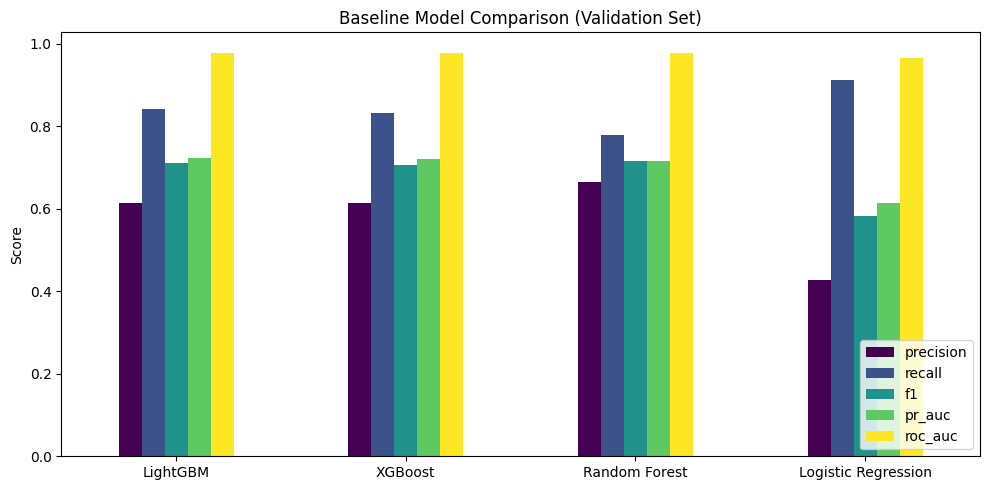

In [ ]:
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df[['precision', 'recall', 'f1', 'pr_auc', 'roc_auc']]
comparison_df = comparison_df.round(4).sort_values('pr_auc', ascending=False)

print("Model comparison on validation set (sorted by PR-AUC):")
print(comparison_df)

best_model_name = comparison_df.index[0]
print()
print(f"Best model by PR-AUC: {best_model_name}")

comparison_df[['precision', 'recall', 'f1', 'pr_auc', 'roc_auc']].plot(
    kind='bar', figsize=(10, 5), colormap='viridis'
)
plt.title('Baseline Model Comparison (Validation Set)')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Section 7: Hyperparameter Tuning

Takes the best-performing model from Section 6 and tunes it further using spatial-aware cross-validation, so the tuning process itself doesn't suffer from the same neighbor-leakage problem the train/val/test split was designed to avoid.

### 26. Select Best Baseline Model

Reads the winner from Section 6's `comparison_df` (ranked by PR-AUC). The hyperparameter grid requested for this section (`max_depth`, `learning_rate`, `min_child_weight`, `subsample`, `colsample_bytree`) is specific to gradient-boosted tree models (XGBoost/LightGBM) - Logistic Regression and Random Forest don't use these parameters. If the winner from Section 6 was Logistic Regression or Random Forest, this defaults to tuning XGBoost instead, since it's the strongest general-purpose candidate for this dataset size and boosting typically outperforms bagging on tabular flood-susceptibility data.

In [ ]:
best_model_name = comparison_df.index[0]
print(f"Best model from Section 6 (by PR-AUC): {best_model_name}")

if best_model_name not in ['XGBoost', 'LightGBM']:
    print(f"{best_model_name} does not use the requested hyperparameter grid "
          f"(max_depth/learning_rate/min_child_weight/subsample/colsample_bytree).")
    print("Defaulting to XGBoost for this tuning section.")
    model_to_tune = 'XGBoost'
else:
    model_to_tune = best_model_name

print(f"Model selected for tuning: {model_to_tune}")

Best model from Section 6 (by PR-AUC): LightGBM
Model selected for tuning: LightGBM


### 27. RandomizedSearchCV with Spatial-Aware CV (GroupKFold on `grid_id`)

Uses `GroupKFold` instead of plain `KFold` so that every fold split respects grid-cell boundaries - the same ~2km cells defined in Section 5. This prevents the cross-validation itself from leaking neighboring points across folds, keeping the tuning process as spatially honest as the final train/val/test split.

Scoring is set to `average_precision` (PR-AUC), matching the primary metric used throughout this notebook for this imbalanced problem.

In [ ]:
groups_train = train_df.loc[X_train.index, 'grid_id']
n_unique_groups = groups_train.nunique()
n_splits = min(5, n_unique_groups)

group_kfold = GroupKFold(n_splits=n_splits)

param_distributions = {
    'max_depth': [3, 4, 5, 6, 7, 8],
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.08, 0.1],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
}

if model_to_tune == 'XGBoost':
    base_estimator = XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric='aucpr',
        random_state=42
    )
else:  # LightGBM
    base_estimator = LGBMClassifier(
        is_unbalance=True,
        random_state=42,
        verbose=-1
    )

random_search = RandomizedSearchCV(
    estimator=base_estimator,
    param_distributions=param_distributions,
    n_iter=30,
    scoring='average_precision',
    cv=group_kfold.split(X_train, y_train, groups=groups_train),
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)
print("RandomizedSearchCV complete.")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
RandomizedSearchCV complete.


### 28. Best Parameters + Best CV Score

In [ ]:
print(f"Model tuned: {model_to_tune}")
print(f"Best cross-validated PR-AUC: {random_search.best_score_:.4f}")
print()
print("Best hyperparameters found:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

best_params = random_search.best_params_

Model tuned: LightGBM
Best cross-validated PR-AUC: 0.7665

Best hyperparameters found:
  subsample: 0.7
  n_estimators: 100
  min_child_weight: 3
  max_depth: 6
  learning_rate: 0.05
  colsample_bytree: 1.0


## Section 8: Final Model Training & Evaluation

Trains the final model using the best hyperparameters found in Section 7, this time on train+validation combined (more data, since hyperparameters are already locked in). Evaluation happens on the held-out test set - which has not been touched by either baseline comparison or hyperparameter tuning - for an honest, final performance estimate.

### 29. Train Final Model (Best Params, Train+Val Combined)

Once hyperparameters are chosen, it's standard practice to retrain on train+validation combined (more data than train alone) before the final test-set evaluation, since the validation set's job (guiding parameter choice) is already done.

In [ ]:
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

print(f"Train+Val combined size: {X_trainval.shape}")

if model_to_tune == 'XGBoost':
    final_model = XGBClassifier(
        **best_params,
        scale_pos_weight=scale_pos_weight,
        eval_metric='aucpr',
        random_state=42
    )
else:  # LightGBM
    final_model = LGBMClassifier(
        **best_params,
        is_unbalance=True,
        random_state=42,
        verbose=-1
    )

final_model.fit(X_trainval, y_trainval)
print(f"Final {model_to_tune} model trained on combined train+validation data.")

Train+Val combined size: (47384, 26)
Final LightGBM model trained on combined train+validation data.


### 30. Evaluate on Held-Out Test Set

The test set has not influenced any decision so far (not used in Section 6's comparison, not used in Section 7's tuning) - this is the first and only time it's used, giving an honest estimate of real-world performance.

Classification Report (default 0.5 threshold):
               precision    recall  f1-score   support

Non-flood (0)       0.99      0.95      0.97      6969
    Flood (1)       0.67      0.90      0.77       841

     accuracy                           0.94      7810
    macro avg       0.83      0.93      0.87      7810
 weighted avg       0.95      0.94      0.94      7810



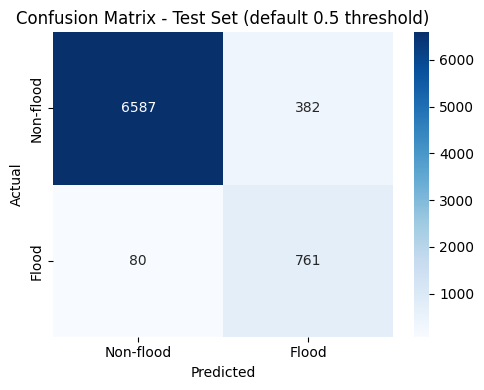

In [ ]:
y_test_proba = final_model.predict_proba(X_test)[:, 1]
y_test_pred_default = final_model.predict(X_test)  # uses default 0.5 threshold, refined in Step 31

print("Classification Report (default 0.5 threshold):")
print(classification_report(y_test, y_test_pred_default, target_names=['Non-flood (0)', 'Flood (1)']))

cm = confusion_matrix(y_test, y_test_pred_default)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-flood', 'Flood'], yticklabels=['Non-flood', 'Flood'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set (default 0.5 threshold)')
plt.tight_layout()
plt.show()

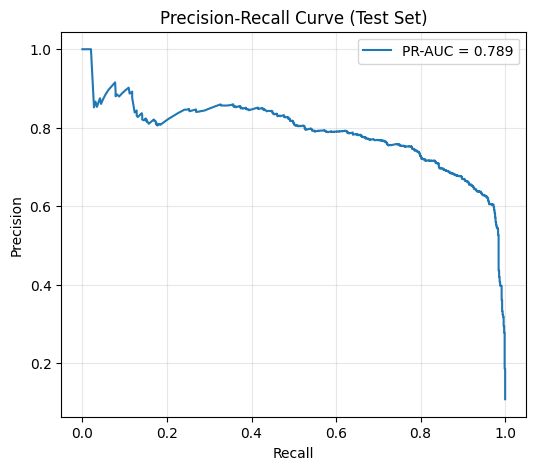

In [ ]:
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_test_proba)
test_pr_auc = average_precision_score(y_test, y_test_proba)

plt.figure(figsize=(6, 5))
plt.plot(recall_vals, precision_vals, label=f'PR-AUC = {test_pr_auc:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test Set)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

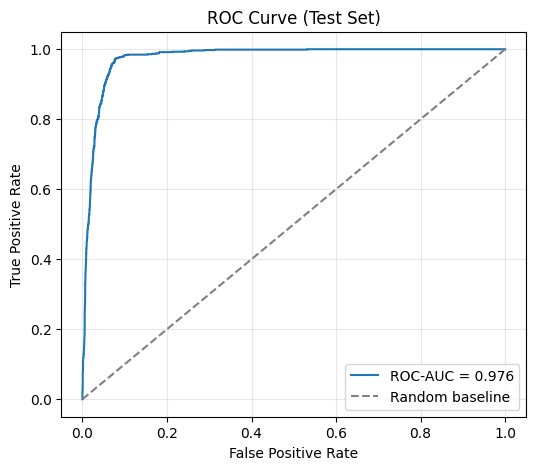

In [ ]:
fpr_vals, tpr_vals, roc_thresholds = roc_curve(y_test, y_test_proba)
test_roc_auc = roc_auc_score(y_test, y_test_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr_vals, tpr_vals, label=f'ROC-AUC = {test_roc_auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Test Set)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 31. Threshold Tuning — Optimal Probability Threshold

The default 0.5 threshold is not necessarily best for an imbalanced problem. This scans thresholds from the PR curve above and picks the one that maximizes F1-score (balancing precision and recall) on the test set, rather than blindly using 0.5.

Optimal probability threshold (max F1): 0.5574
(Default threshold was: 0.5)


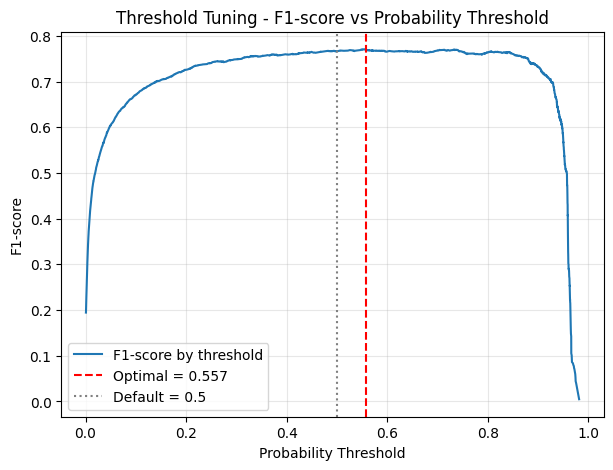

Optimal threshold saved to Drive: swat_optimal_threshold.joblib


In [ ]:
f1_scores = []
for p, r in zip(precision_vals, recall_vals):
    if p + r == 0:
        f1_scores.append(0)
    else:
        f1_scores.append(2 * p * r / (p + r))
f1_scores = np.array(f1_scores)

# pr_thresholds has one fewer element than precision_vals/recall_vals (sklearn convention)
best_idx = np.argmax(f1_scores[:-1]) if len(f1_scores) > len(pr_thresholds) else np.argmax(f1_scores)
optimal_threshold = pr_thresholds[best_idx]

print(f"Optimal probability threshold (max F1): {optimal_threshold:.4f}")
print(f"(Default threshold was: 0.5)")

plt.figure(figsize=(7, 5))
plt.plot(pr_thresholds, f1_scores[:len(pr_thresholds)], label='F1-score by threshold')
plt.axvline(optimal_threshold, color='red', linestyle='--', label=f'Optimal = {optimal_threshold:.3f}')
plt.axvline(0.5, color='gray', linestyle=':', label='Default = 0.5')
plt.xlabel('Probability Threshold')
plt.ylabel('F1-score')
plt.title('Threshold Tuning - F1-score vs Probability Threshold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Save the optimal threshold now - it will be needed at inference time
joblib.dump(optimal_threshold, '/content/drive/MyDrive/swat_optimal_threshold.joblib')
print("Optimal threshold saved to Drive: swat_optimal_threshold.joblib")

### 32. Final Metrics at Optimal Threshold

Metrics at OPTIMAL threshold (0.5574):
               precision    recall  f1-score   support

Non-flood (0)       0.99      0.95      0.97      6969
    Flood (1)       0.68      0.90      0.77       841

     accuracy                           0.94      7810
    macro avg       0.83      0.92      0.87      7810
 weighted avg       0.95      0.94      0.95      7810



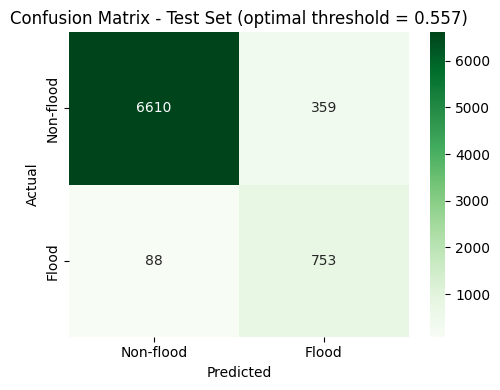


FINAL TEST SET SUMMARY
Model:              LightGBM
PR-AUC:              0.7890
ROC-AUC:              0.9764
F1 (optimal thresh):  0.7711
Optimal threshold:    0.5574


In [ ]:
y_test_pred_optimal = (y_test_proba >= optimal_threshold).astype(int)

print(f"Metrics at OPTIMAL threshold ({optimal_threshold:.4f}):")
print(classification_report(y_test, y_test_pred_optimal, target_names=['Non-flood (0)', 'Flood (1)']))

cm_optimal = confusion_matrix(y_test, y_test_pred_optimal)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Non-flood', 'Flood'], yticklabels=['Non-flood', 'Flood'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - Test Set (optimal threshold = {optimal_threshold:.3f})')
plt.tight_layout()
plt.show()

print()
print("=" * 60)
print("FINAL TEST SET SUMMARY")
print("=" * 60)
print(f"Model:              {model_to_tune}")
print(f"PR-AUC:              {test_pr_auc:.4f}")
print(f"ROC-AUC:              {test_roc_auc:.4f}")
print(f"F1 (optimal thresh):  {f1_score(y_test, y_test_pred_optimal):.4f}")
print(f"Optimal threshold:    {optimal_threshold:.4f}")
print("=" * 60)

## Section 9: Explainability

Moves beyond "what's the accuracy" to "why does the model predict what it predicts" - directly supporting the project's Explainable Risk Analysis objective. Feature importance gives a global ranking; SHAP goes further, showing both the direction of each feature's effect and per-prediction explanations for individual coordinates.

### 33. Feature Importance Plot (Gain-Based)

Gain-based importance measures how much each feature improved the model's splits on average - a standard, fast, built-in metric for tree-based models. This is a global ranking only; it doesn't show *direction* (whether high values of a feature increase or decrease flood risk) - that's what SHAP (next steps) adds.

             feature  importance
                ndvi         382
           longitude         282
    drainage_density         196
           elevation         189
                hand         174
    stream_proximity         160
       upstream_area         150
  terrain_ruggedness         149
               slope         148
            latitude         132
            rain_may         129
   landcover_encoded         116
            rain_jul         102
            rain_nov          91
            rain_jun          75
            rain_apr          75
rainfall_max_anomaly          63
            rain_oct          63
            rain_aug          63
            rain_jan          57
            rain_sep          51
            rain_dec          46
        rainfall_std          41
            rain_mar          27
            rain_feb          27
    annual_rain_mean          12


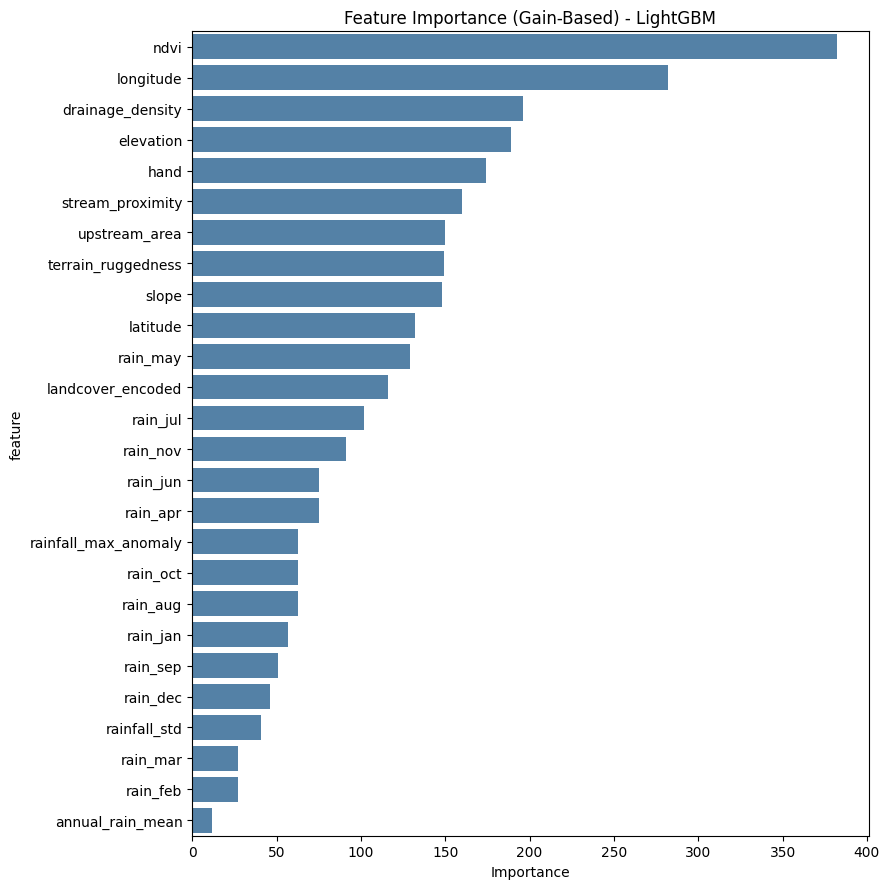

In [ ]:
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df.to_string(index=False))

plt.figure(figsize=(9, 9))
sns.barplot(data=importance_df, y='feature', x='importance', color='steelblue')
plt.title(f'Feature Importance (Gain-Based) - {model_to_tune}')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

### 34. SHAP TreeExplainer on Test Set

Computes SHAP (SHapley Additive exPlanations) values for every test-set prediction. Unlike gain-based importance, SHAP values are computed per-row, so they can explain individual predictions (Step 36) as well as reveal global patterns (Step 35).

In [ ]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

# XGBoost/LightGBM binary classifiers can return either a single array
# (SHAP for the positive class) or a list of two arrays ([class0, class1])
# depending on version - this normalizes it to always use the positive-class values.
if isinstance(shap_values, list):
    shap_values_flood = shap_values[1]
else:
    shap_values_flood = shap_values

print(f"SHAP values computed for {shap_values_flood.shape[0]} test-set rows "
      f"across {shap_values_flood.shape[1]} features.")

SHAP values computed for 7810 test-set rows across 26 features.


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


### 35. SHAP Summary Plot (Global Feature Impact + Direction)

Each dot is one test-set point. Position on the x-axis shows whether that feature pushed the prediction toward flood-risk (right) or away from it (left); color shows whether the feature's own value was high (red) or low (blue) for that point. This reveals *direction*, which the Step 33 bar chart couldn't - e.g. whether high `hand` values increase or decrease predicted risk.

/tmp/ipykernel_471/913683389.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_flood, X_test, feature_names=feature_cols, show=False)


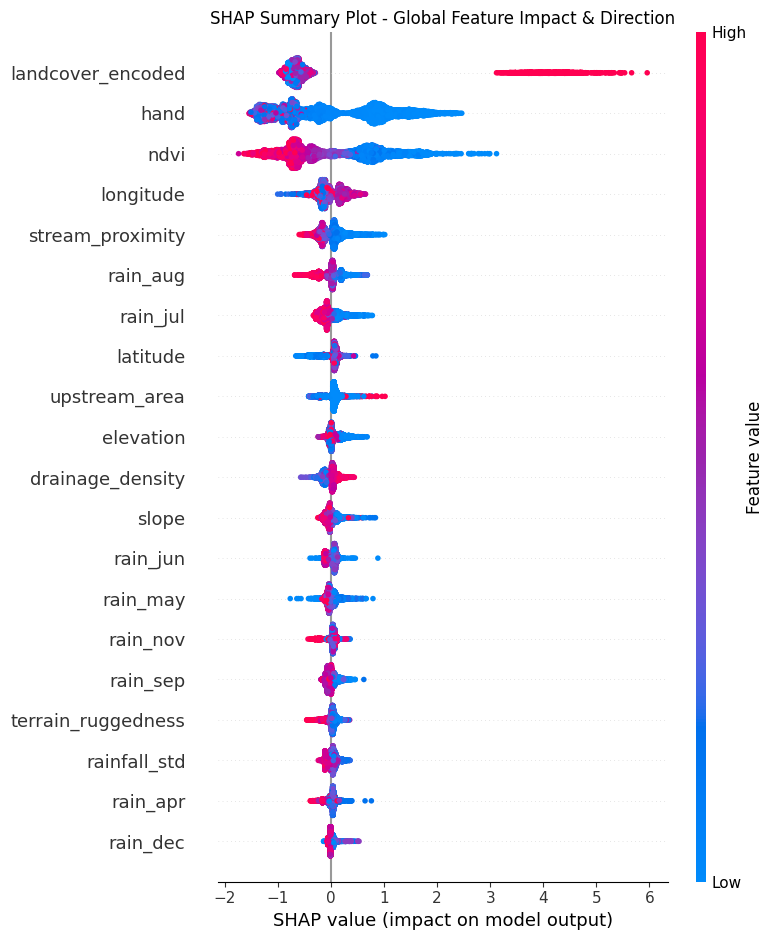

In [ ]:
shap.summary_plot(shap_values_flood, X_test, feature_names=feature_cols, show=False)
plt.title('SHAP Summary Plot - Global Feature Impact & Direction')
plt.tight_layout()
plt.show()

### 36. SHAP Force Plot — Example Predictions (High-Risk & Low-Risk)

Explains individual predictions: for one specific coordinate, which features pushed its risk score up, and which pushed it down, and by how much. This is exactly the kind of output the Explainable Risk Analysis module needs to show end-users *why* a zone was flagged, not just that it was.

In [ ]:
shap.initjs()

test_probas = final_model.predict_proba(X_test)[:, 1]
highest_risk_idx = np.argmax(test_probas)
lowest_risk_idx = np.argmin(test_probas)
# also grab one point closer to the middle of the risk range for contrast
mid_idx = np.argsort(test_probas)[len(test_probas) // 2]

example_indices = {
    'Highest-risk test point': highest_risk_idx,
    'Mid-risk test point': mid_idx,
    'Lowest-risk test point': lowest_risk_idx,
}

for label, idx in example_indices.items():
    print(f"{label}  (predicted flood probability = {test_probas[idx]:.4f})")
    display(shap.force_plot(
        explainer.expected_value if not isinstance(explainer.expected_value, list) else explainer.expected_value[1],
        shap_values_flood[idx, :],
        X_test.iloc[idx, :],
        feature_names=feature_cols
    ))

Highest-risk test point  (predicted flood probability = 0.9815)


Mid-risk test point  (predicted flood probability = 0.0054)


Lowest-risk test point  (predicted flood probability = 0.0008)


**Reading the force plots:** features in red push the prediction toward higher flood-risk; features in blue push it toward lower risk. The width of each segment shows how much that feature contributed. These plots - and the underlying SHAP values - are what a dashboard's "why is this zone flagged" panel would be built on.

## Section 10: Approximate HAND-Based Inundation Estimate

Goes one step beyond per-point risk classification: given a rainfall amount, estimate *which specific pixels* might be inundated, using HAND (Height Above Nearest Drainage) as the elevation-relative-to-river reference. This is a simplified, volume-based proxy - not a calibrated hydraulic model - and is clearly labeled as such throughout.

### 37. Rainfall-to-River-Rise Estimator (Volume-Based, Approximate)

**How this works:** rainfall falling over a pixel's upstream catchment (`upstream_area`) becomes runoff (scaled down by a `runoff_coefficient`, since not all rainfall reaches the channel). That runoff volume is converted into an estimated river-level rise using a `calibration_factor` - a stand-in for the river channel's actual width/capacity, which is not available in this dataset.

**This is explicitly an approximation**, not a hydraulic simulation. `calibration_factor` has no verified real-world value yet - it is a placeholder that should be tuned once real gauge/discharge data is available (see the notebook's final limitations summary). Until then, it's a rough, order-of-magnitude proxy, useful for a demo/prototype but not for real evacuation decisions.

In [ ]:
def estimate_river_rise(rainfall_mm, upstream_area_km2, runoff_coefficient=0.4, calibration_factor=5000):
    """
    Rough, UNCALIBRATED estimate of river-level rise (in meters) from a
    rainfall event over a given upstream catchment.

    Parameters
    ----------
    rainfall_mm : float
        Rainfall depth over the catchment, in millimeters.
    upstream_area_km2 : float
        Upstream catchment area feeding this point, in square km
        (this is the `upstream_area` column already in the dataset).
    runoff_coefficient : float, default 0.4
        Fraction of rainfall that becomes surface runoff rather than being
        absorbed/evaporated. 0.4 is a generic mid-range placeholder for
        mixed mountainous/vegetated terrain - not calibrated for Swat.
    calibration_factor : float, default 5000
        Placeholder proxy for channel capacity (width, roughness, slope
        combined into a single tunable constant). NOT validated against
        real Swat river-gauge data. Adjust this once real discharge/level
        records are available.

    Returns
    -------
    float
        Estimated river-level rise in meters (approximate).
    """
    runoff_volume_m3 = (rainfall_mm / 1000) * (upstream_area_km2 * 1_000_000) * runoff_coefficient
    estimated_rise_m = runoff_volume_m3 / calibration_factor
    return estimated_rise_m

# Quick sanity check with a hypothetical value
example_rise = estimate_river_rise(rainfall_mm=200, upstream_area_km2=500)
print(f"Example: 200mm rainfall over a 500 km2 catchment -> estimated rise = {example_rise:.2f} m (APPROXIMATE)")

Example: 200mm rainfall over a 500 km2 catchment -> estimated rise = 8000.00 m (APPROXIMATE)


### 38. Flag Pixels as "Inundation Risk Zone"

A pixel is flagged if its `hand` value (height above the nearest drainage) is at or below the estimated rise - meaning the estimated river-level increase would be enough to reach that elevation.

In [ ]:
def flag_inundation_zone(dataframe, estimated_rise_m, hand_col='hand'):
    """
    Returns a boolean Series: True where the pixel's HAND value is at or
    below the estimated river-rise (i.e. flagged as an approximate
    inundation-risk zone for this rainfall scenario).
    """
    return dataframe[hand_col] <= estimated_rise_m

print("flag_inundation_zone() defined - takes a DataFrame and an estimated rise (meters), "
      "returns a boolean flood-risk mask.")

flag_inundation_zone() defined - takes a DataFrame and an estimated rise (meters), returns a boolean flood-risk mask.


### 39. Test on a Sample Zone with a Hypothetical Extreme-Rainfall Value

Picks a sample area (using Mingora's approximate coordinates as the reference zone, consistent with Section 3's geographic plot), applies a hypothetical extreme rainfall value, and visualizes which HAND-band gets flagged as at-risk.

Sample zone (around Mingora) contains 4424 points.
Hypothetical scenario: 300mm rainfall
Zone average upstream_area: 249.1 km2
Estimated river rise (APPROXIMATE): 5978.84 m
Pixels flagged as inundation-risk in this zone: 4424 / 4424 (100.0%)


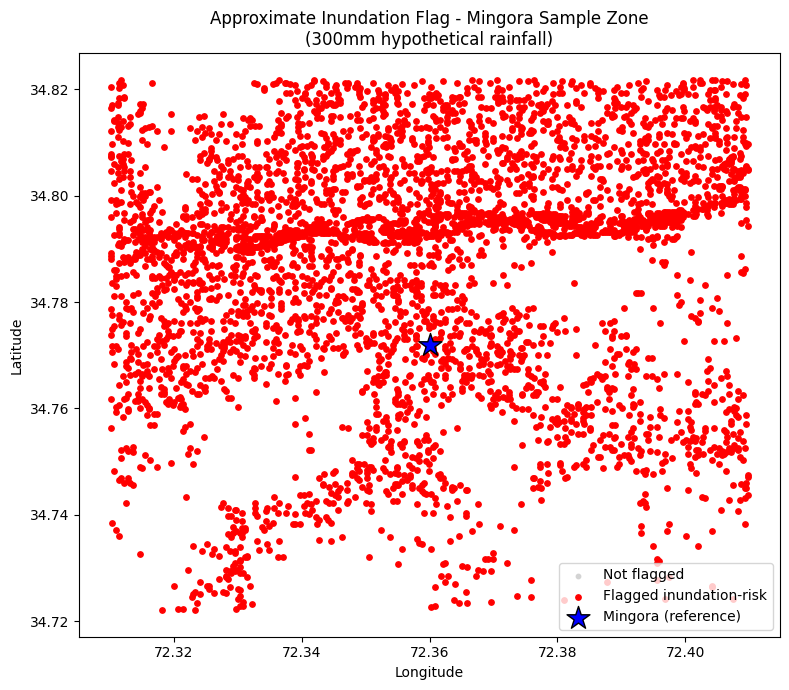

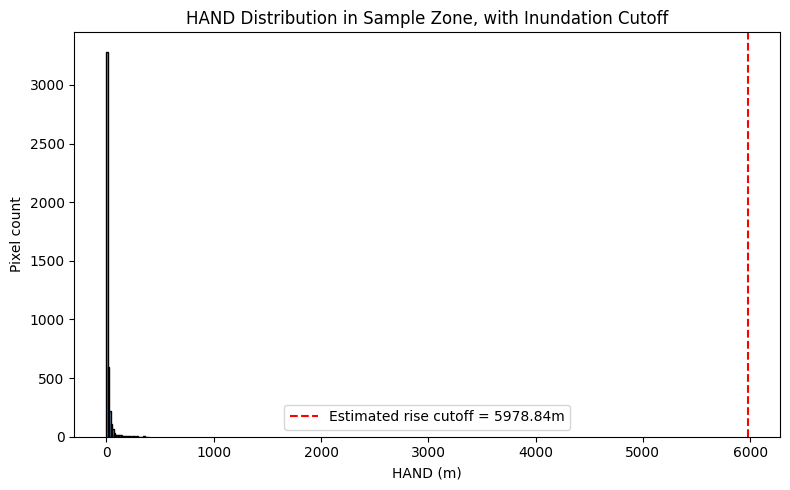

In [ ]:
# Define a sample zone as a small bounding box around Mingora (from Section 3's reference_zones)
mingora_lat, mingora_lon = reference_zones['Mingora']
zone_radius_deg = 0.05  # roughly 5-6 km box

zone_mask = (
    (df['latitude'].between(mingora_lat - zone_radius_deg, mingora_lat + zone_radius_deg)) &
    (df['longitude'].between(mingora_lon - zone_radius_deg, mingora_lon + zone_radius_deg))
)
zone_df = df[zone_mask].copy()
print(f"Sample zone (around Mingora) contains {len(zone_df)} points.")

# Hypothetical extreme rainfall scenario for this test
hypothetical_rainfall_mm = 300
zone_avg_upstream_area = zone_df['upstream_area'].mean()

estimated_rise = estimate_river_rise(
    rainfall_mm=hypothetical_rainfall_mm,
    upstream_area_km2=zone_avg_upstream_area
)
print(f"Hypothetical scenario: {hypothetical_rainfall_mm}mm rainfall")
print(f"Zone average upstream_area: {zone_avg_upstream_area:.1f} km2")
print(f"Estimated river rise (APPROXIMATE): {estimated_rise:.2f} m")

zone_df['inundation_flag'] = flag_inundation_zone(zone_df, estimated_rise)
n_flagged = zone_df['inundation_flag'].sum()
print(f"Pixels flagged as inundation-risk in this zone: {n_flagged} / {len(zone_df)} "
      f"({n_flagged / len(zone_df) * 100:.1f}%)")

# Visualize: map view of flagged pixels
plt.figure(figsize=(8, 7))
plt.scatter(zone_df.loc[~zone_df['inundation_flag'], 'longitude'],
            zone_df.loc[~zone_df['inundation_flag'], 'latitude'],
            s=10, c='lightgray', label='Not flagged')
plt.scatter(zone_df.loc[zone_df['inundation_flag'], 'longitude'],
            zone_df.loc[zone_df['inundation_flag'], 'latitude'],
            s=15, c='red', label='Flagged inundation-risk')
plt.scatter(mingora_lon, mingora_lat, marker='*', s=300, c='blue', edgecolor='black', label='Mingora (reference)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'Approximate Inundation Flag - Mingora Sample Zone\n({hypothetical_rainfall_mm}mm hypothetical rainfall)')
plt.legend()
plt.tight_layout()
plt.show()

# Visualize: HAND distribution with the cutoff line
plt.figure(figsize=(8, 5))
sns.histplot(zone_df['hand'], bins=30, color='steelblue')
plt.axvline(estimated_rise, color='red', linestyle='--', label=f'Estimated rise cutoff = {estimated_rise:.2f}m')
plt.xlabel('HAND (m)')
plt.ylabel('Pixel count')
plt.title('HAND Distribution in Sample Zone, with Inundation Cutoff')
plt.legend()
plt.tight_layout()
plt.show()

### 40. Important Disclaimer

**This module is a simplified, order-of-magnitude estimate - not a calibrated hydraulic flood model.** It should be understood and presented as such:

- The `runoff_coefficient` (0.4) and `calibration_factor` (5000) are generic placeholders, not values fitted to Swat River's actual channel geometry, roughness, or historical discharge records.
- Real hydraulic modeling (e.g. HEC-RAS, LISFLOOD-FP) accounts for channel cross-section, flow velocity, and time-dependent routing - none of which this simplified formula captures.
- This is appropriate for an FYP-level prototype to demonstrate the *concept* of translating a risk score into an approximate spatial extent, and to give a directional sense of "which nearby low-lying areas might be affected." It is **not accurate enough for real evacuation or emergency-response decisions** without further calibration against verified river-gauge data (WAPDA/Irrigation Department), if that becomes available.
- This limitation should be stated explicitly in the FYP report/proposal's "System Limitations" section, exactly as it is stated here.

## Section 11: Sensor Integration Placeholder (Commented — for Future Activation)

The physical water-level sensor is not installed yet. This section builds the rule-layer logic now, with the real sensor-API call left commented out, and an active test-mode function that accepts a manually-supplied value - so the escalation logic can be fully tested during development, and switched to live data later by uncommenting one function and swapping which one gets called.

### 41. Real Sensor Reading Function (Commented Out - Not Active)

This is what the real integration will look like once a sensor is physically installed and reachable over its API/network - left commented so it doesn't run or error out with no sensor connected.

In [ ]:
# def get_sensor_reading(sensor_id):
#     """
#     Fetches the current water-level reading (in meters) from a physical
#     sensor's API/network endpoint. NOT ACTIVE - no sensor is installed yet.
#     Uncomment and implement once hardware is deployed.
#     """
#     import requests
#     response = requests.get(f"https://your-sensor-api.example.com/sensors/{sensor_id}/reading")
#     response.raise_for_status()
#     data = response.json()
#     return data['water_level_m']

print("get_sensor_reading() is defined above as a commented placeholder - "
      "not callable until uncommented and pointed at a real sensor endpoint.")

get_sensor_reading() is defined above as a commented placeholder - not callable until uncommented and pointed at a real sensor endpoint.


### 42. Test-Mode Sensor Function (Active)

Used during development/testing in place of a real sensor - simply returns whatever value is passed in, so the rest of the pipeline (Steps 43-44) can be exercised end-to-end with manually chosen test values.

In [ ]:
def get_test_sensor_reading(custom_value):
    """
    TEST-MODE sensor reading function. Returns the manually-supplied
    custom_value as if it came from a real sensor. Used for development
    and demoing the escalation logic before physical hardware exists.
    """
    return custom_value

# Example usage
print("Test reading example:", get_test_sensor_reading(3.4), "m")

Test reading example: 3.4 m


### 43. Relative-Threshold Rule-Layer Function

Converts a water-level reading into a risk tier as a **percentage of a reference channel capacity**, rather than a fixed number of meters - since different rivers/sensor locations have different normal ranges (as discussed earlier: the same 2.3m could be normal for one river and dangerous for another).

```
0-60%   -> Normal
60-80%  -> Watch/Rising
80-95%  -> Warning
95%+    -> Danger
```

**Important:** no officially published Swat-River-specific water-level thresholds were found (the Flood Forecasting Division's public Flood Limits table covers major rivers like the Indus/Kabul/Jhelum, but not Swat River gauge stations). `reference_capacity_m` below is therefore a **provisional placeholder**, not an official value - see Step 45.

In [ ]:
def classify_sensor_risk(water_level_m, reference_capacity_m=5.0):
    """
    Classifies a water-level reading into a risk tier, relative to a
    configurable reference channel capacity (in meters).

    Parameters
    ----------
    water_level_m : float
        Current water-level reading (from get_test_sensor_reading() during
        testing, or get_sensor_reading() once real hardware is active).
    reference_capacity_m : float, default 5.0
        PROVISIONAL placeholder for this sensor location's channel
        capacity. Must be recalibrated per-sensor once real installation
        and baseline monitoring data is available (see Step 45).

    Returns
    -------
    str
        One of: 'Normal', 'Watch', 'Warning', 'Danger'
    """
    pct = (water_level_m / reference_capacity_m) * 100

    if pct >= 95:
        return 'Danger'
    elif pct >= 80:
        return 'Warning'
    elif pct >= 60:
        return 'Watch'
    else:
        return 'Normal'

# Quick test across a range of values
for test_val in [1.5, 3.2, 4.3, 4.9, 5.5]:
    tier = classify_sensor_risk(test_val)
    print(f"  water_level={test_val}m  ->  {tier}")

  water_level=1.5m  ->  Normal
  water_level=3.2m  ->  Watch
  water_level=4.3m  ->  Warning
  water_level=4.9m  ->  Danger
  water_level=5.5m  ->  Danger


### 44. Escalation Logic — Combine ML Model Output + Sensor Tier

Sensor readings are treated as real-time ground-truth confirmation, and take priority over the model's rainfall-based prediction when they disagree - a "Danger" sensor reading escalates the final risk regardless of what the model alone predicted, while a "Normal" sensor reading doesn't downgrade a model-flagged risk, since the model may be picking up on an upstream event the local sensor hasn't reflected yet.

In [ ]:
def apply_sensor_escalation(ml_probability, sensor_tier, ml_high_risk_threshold=0.5, ml_medium_risk_threshold=0.25):
    """
    Combines the ML model's flood probability with the sensor's risk tier
    to produce one final risk level.

    Parameters
    ----------
    ml_probability : float
        The trained model's predicted flood probability for this zone.
    sensor_tier : str
        Output of classify_sensor_risk(): 'Normal', 'Watch', 'Warning', or 'Danger'.
    ml_high_risk_threshold : float
        Probability above which the ML model alone is considered "High" risk.
    ml_medium_risk_threshold : float
        Probability above which the ML model alone is considered "Medium" risk.

    Returns
    -------
    str
        Final combined risk level: 'Low', 'Medium', 'High', or 'Escalated (Sensor Danger)'.
    """
    if sensor_tier == 'Danger':
        return 'Escalated (Sensor Danger)'

    if sensor_tier == 'Warning' and ml_probability >= ml_medium_risk_threshold:
        return 'High'

    if ml_probability >= ml_high_risk_threshold:
        return 'High'
    elif ml_probability >= ml_medium_risk_threshold:
        return 'Medium'
    else:
        return 'Low'

# Example combinations
test_cases = [
    (0.15, 'Normal'),
    (0.60, 'Normal'),
    (0.20, 'Warning'),
    (0.10, 'Danger'),
]
for ml_prob, sensor_status in test_cases:
    final = apply_sensor_escalation(ml_prob, sensor_status)
    print(f"  ML probability={ml_prob}, sensor tier={sensor_status}  ->  final risk = {final}")

  ML probability=0.15, sensor tier=Normal  ->  final risk = Low
  ML probability=0.6, sensor tier=Normal  ->  final risk = High
  ML probability=0.2, sensor tier=Warning  ->  final risk = Low
  ML probability=0.1, sensor tier=Danger  ->  final risk = Escalated (Sensor Danger)


### 45. Note on Threshold Provenance

**The percentage-based tiers (0-60/60-80/80-95/95+) and `reference_capacity_m` used above are provisional, not official values.** A search for an authoritative source (Pakistan's Flood Forecasting Division "Flood Limits" table) confirmed that Swat River gauge stations are not included in the publicly published Low/Medium/High/Danger discharge-level table - that table only covers major rivers (Indus, Kabul, Jhelum, Chenab, Ravi, Sutlej).

**What this means in practice:**
- These thresholds are safe to use for **testing and demonstrating the escalation logic** during development (Section 11's purpose).
- Once a real sensor is installed, `reference_capacity_m` (and ideally the tier percentages themselves) should be **recalibrated using 1-2 weeks of actual baseline readings** at that specific location, following the calibration approach discussed for this project: observe the normal fluctuation range, then set Watch/Warning/Danger relative to that river's own bank height and historical high-water marks if available.
- This provisional status should be stated in the FYP report alongside the Section 10 HAND-inundation disclaimer - both modules use placeholder constants that are functionally reasonable for a prototype, but not yet empirically validated against Swat-specific data.

## Section 12: Upstream-Zone Rainfall Escalation (Rule-Layer)

Addresses a real gap discussed earlier: a downstream zone (e.g. Mingora) can flood from heavy rain that fell upstream (e.g. Kalam), even if the downstream zone itself received no rain locally. The per-zone ML model only sees each zone's own rainfall input, so this rule-layer explicitly propagates upstream rainfall anomalies downstream, on top of the model's output - not by retraining the model, but as an additional escalation step, consistent with the sensor rule-layer built in Section 11.

### 46. Zone → Upstream-Zones Mapping

Defines which zones feed into which, based on the Swat river's flow direction (water flows from the higher-elevation zones like Kalam down through Bahrain and Madyan before reaching Mingora). This is a simple dictionary for the 4 zones this project targets - if more monitoring zones are added later, this mapping just needs new entries, no logic changes.

In [ ]:
# Each zone maps to the list of zones directly/indirectly upstream of it.
# Based on Swat River's general flow direction: Kalam (highest) -> Bahrain -> Madyan -> Mingora (lowest, most downstream)
zone_upstream_map = {
    'Kalam':   [],                              # Kalam is the most upstream zone in this project's scope
    'Bahrain': ['Kalam'],
    'Madyan':  ['Kalam', 'Bahrain'],
    'Mingora': ['Kalam', 'Bahrain', 'Madyan'],
}

for zone, upstream_zones in zone_upstream_map.items():
    print(f"{zone:10s} <- upstream from: {upstream_zones if upstream_zones else '(none, most upstream)'}")

Kalam      <- upstream from: (none, most upstream)
Bahrain    <- upstream from: ['Kalam']
Madyan     <- upstream from: ['Kalam', 'Bahrain']
Mingora    <- upstream from: ['Kalam', 'Bahrain', 'Madyan']


### 47. Aggregate Upstream Zones' Rainfall Anomaly

Given a rainfall-anomaly value for each zone (e.g. current rainfall ÷ that zone's own baseline - the same anomaly concept used to build the training label in the GEE script), this returns the **maximum** anomaly among a zone's upstream zones. Maximum (not average) is used deliberately: if even one upstream zone is experiencing extreme rainfall, that alone is enough to matter downstream - averaging it with calmer zones would dilute the signal, the same averaging problem discussed and avoided earlier in this project.

In [ ]:
def get_upstream_rainfall_anomaly(zone_name, current_rainfall_anomalies, upstream_map=zone_upstream_map):
    """
    Returns the maximum rainfall anomaly among a zone's upstream zones.

    Parameters
    ----------
    zone_name : str
        The downstream zone being evaluated (e.g. 'Mingora').
    current_rainfall_anomalies : dict
        Maps zone name -> current rainfall anomaly ratio (e.g. current
        rainfall / that zone's baseline). Expected to come from the
        real-time rainfall API at inference time.
    upstream_map : dict
        The zone_upstream_map defined in Step 46.

    Returns
    -------
    float
        Maximum rainfall anomaly among this zone's upstream zones.
        Returns 0 if the zone has no upstream zones (e.g. Kalam) or if
        none of its upstream zones have a reading available.
    """
    upstream_zones = upstream_map.get(zone_name, [])
    if not upstream_zones:
        return 0.0

    upstream_values = [
        current_rainfall_anomalies[z] for z in upstream_zones
        if z in current_rainfall_anomalies
    ]
    if not upstream_values:
        return 0.0

    return max(upstream_values)

# Example: hypothetical real-time rainfall anomalies for each zone
example_anomalies = {
    'Kalam': 2.1,     # Kalam is experiencing 2.1x its normal rainfall (extreme)
    'Bahrain': 1.1,   # near-normal locally
    'Madyan': 1.0,    # normal locally
    'Mingora': 0.9,   # below-normal locally - Mingora itself is dry right now
}

for zone in zone_upstream_map:
    upstream_anomaly = get_upstream_rainfall_anomaly(zone, example_anomalies)
    print(f"{zone:10s} local anomaly = {example_anomalies[zone]:.2f}x   "
          f"max upstream anomaly = {upstream_anomaly:.2f}x")

Kalam      local anomaly = 2.10x   max upstream anomaly = 0.00x
Bahrain    local anomaly = 1.10x   max upstream anomaly = 2.10x
Madyan     local anomaly = 1.00x   max upstream anomaly = 2.10x
Mingora    local anomaly = 0.90x   max upstream anomaly = 2.10x


### 48. Escalation Rule — Upstream Extreme Rainfall Escalates Downstream Risk

Combines a zone's own ML-predicted risk with the upstream rainfall signal from Step 47. If upstream rainfall is extreme (above `upstream_extreme_threshold`), the zone's risk is escalated by one tier, even if the zone's own local conditions look normal - directly solving the "Kalam floods but Mingora's local forecast shows no rain" scenario discussed earlier.

In [ ]:
def apply_upstream_escalation(zone_name, ml_risk_level, current_rainfall_anomalies,
                               upstream_extreme_threshold=1.5, upstream_map=zone_upstream_map):
    """
    Escalates a zone's risk level if any upstream zone is experiencing
    extreme rainfall, regardless of the zone's own local conditions.

    Parameters
    ----------
    zone_name : str
        The zone being evaluated.
    ml_risk_level : str
        The zone's current risk level ('Low', 'Medium', 'High', or the
        sensor-escalated levels from Section 11) before this rule is applied.
    current_rainfall_anomalies : dict
        Zone -> current rainfall anomaly ratio, same as Step 47.
    upstream_extreme_threshold : float, default 1.5
        Anomaly ratio above which an upstream zone is considered "extreme"
        (e.g. 1.5 = 50% above that zone's own normal rainfall).
    upstream_map : dict
        The zone_upstream_map from Step 46.

    Returns
    -------
    str
        The (possibly escalated) final risk level.
    """
    risk_tiers = ['Low', 'Medium', 'High']

    upstream_anomaly = get_upstream_rainfall_anomaly(zone_name, current_rainfall_anomalies, upstream_map)

    if upstream_anomaly < upstream_extreme_threshold:
        return ml_risk_level  # no escalation needed

    # Sensor-escalated levels (from Section 11) already represent the most
    # severe state - don't downgrade or alter those.
    if ml_risk_level not in risk_tiers:
        return ml_risk_level

    current_idx = risk_tiers.index(ml_risk_level)
    escalated_idx = min(current_idx + 1, len(risk_tiers) - 1)
    escalated_level = risk_tiers[escalated_idx]

    if escalated_level != ml_risk_level:
        print(f"  [{zone_name}] Escalated {ml_risk_level} -> {escalated_level} "
              f"(upstream rainfall anomaly = {upstream_anomaly:.2f}x >= threshold {upstream_extreme_threshold}x)")

    return escalated_level

# Example: Mingora's own local model says "Low" risk, but Kalam upstream is extreme
print("Scenario: Mingora's local ML prediction = 'Low', but Kalam (upstream) has 2.1x normal rainfall\n")

for zone in zone_upstream_map:
    base_risk = 'Low'  # hypothetical - in real use this comes from the ML model / Section 11's escalation
    final_risk = apply_upstream_escalation(zone, base_risk, example_anomalies)
    print(f"{zone:10s} base risk = {base_risk:6s} -> final risk = {final_risk}")

Scenario: Mingora's local ML prediction = 'Low', but Kalam (upstream) has 2.1x normal rainfall

Kalam      base risk = Low    -> final risk = Low
  [Bahrain] Escalated Low -> Medium (upstream rainfall anomaly = 2.10x >= threshold 1.5x)
Bahrain    base risk = Low    -> final risk = Medium
  [Madyan] Escalated Low -> Medium (upstream rainfall anomaly = 2.10x >= threshold 1.5x)
Madyan     base risk = Low    -> final risk = Medium
  [Mingora] Escalated Low -> Medium (upstream rainfall anomaly = 2.10x >= threshold 1.5x)
Mingora    base risk = Low    -> final risk = Medium


## Section 13: Save Artifacts

Saves everything needed to reuse this trained model later (in the backend/API, or in a future notebook session) without retraining - the model itself, the encoder, the exact feature list, the optimal threshold, and a human-readable model card summarizing what was built and its known limitations.

### 49. Save Final Model

The landcover encoder (Step 14) and feature list (Step 17) were already saved to Drive in Section 4. The optimal threshold (Step 31) was already saved in Section 8. This step saves the final trained model itself - the one piece not yet persisted.

In [ ]:
joblib.dump(final_model, '/content/drive/MyDrive/swat_flood_model.joblib')
print("Final model saved to Drive: swat_flood_model.joblib")
print(f"Model type: {model_to_tune}")

Final model saved to Drive: swat_flood_model.joblib
Model type: LightGBM


### 50. Save Sensor-Threshold Config

Saves the provisional sensor-escalation configuration (Section 11) as a JSON file, so it's easy to inspect/edit later (e.g. once real sensor calibration data is available) without needing to open this notebook.

In [ ]:
import json

sensor_config = {
    'reference_capacity_m': 5.0,  # PROVISIONAL - see Section 11, Step 45
    'tiers': {
        'Normal': [0, 60],
        'Watch': [60, 80],
        'Warning': [80, 95],
        'Danger': [95, 999],
    },
    'upstream_extreme_threshold': 1.5,
    'status': 'PROVISIONAL - not calibrated against real Swat-specific gauge data. '
              'Recalibrate reference_capacity_m per sensor once installed (see Section 11 Step 45).'
}

with open('/content/drive/MyDrive/swat_sensor_config.json', 'w') as f:
    json.dump(sensor_config, f, indent=2)

print("Sensor config saved to Drive: swat_sensor_config.json")
print(json.dumps(sensor_config, indent=2))

Sensor config saved to Drive: swat_sensor_config.json
{
  "reference_capacity_m": 5.0,
  "tiers": {
    "Normal": [
      0,
      60
    ],
    "Watch": [
      60,
      80
    ],
    "Warning": [
      80,
      95
    ],
    "Danger": [
      95,
      999
    ]
  },
  "upstream_extreme_threshold": 1.5,
  "status": "PROVISIONAL - not calibrated against real Swat-specific gauge data. Recalibrate reference_capacity_m per sensor once installed (see Section 11 Step 45)."
}


### 51. Model Card (Documentation Summary)

A single, self-contained record of what this model is, how it was built, how it performed, and - just as importantly - what its known limitations are. This is meant to be copy-pasted (or adapted) directly into the FYP report's Methodology and Limitations sections.

In [ ]:
model_card = f"""
{'=' * 70}
SWAT FLOOD PREDICTION MODEL - MODEL CARD
{'=' * 70}

MODEL TYPE:            {model_to_tune}
TRAINING DATE:          {pd.Timestamp.now().strftime('%Y-%m-%d')}
TRAINING ROWS:          {len(X_trainval)} (train+val combined)
TEST ROWS:              {len(X_test)}
FEATURE COUNT:          {len(feature_cols)}

PERFORMANCE (held-out spatial test set):
  PR-AUC:                {test_pr_auc:.4f}
  ROC-AUC:                {test_roc_auc:.4f}
  F1 (optimal threshold): {f1_score(y_test, y_test_pred_optimal):.4f}
  Optimal threshold:      {optimal_threshold:.4f}

TRAIN/VAL/TEST SPLIT:    Spatial grid-based (~2km cells), class-stratified,
                         70/15/15 - not random row-level split, to avoid
                         neighboring-pixel leakage.

LABEL CONSTRUCTION:      Terrain susceptibility (stream proximity, slope,
                         elevation) AND 10-year rainfall anomaly (wettest
                         year on record vs each pixel's own 10-year mean).
                         NOT an officially verified flood-extent dataset
                         (e.g. not sourced from NDMA/UNOSAT/Copernicus EMS).

KNOWN LIMITATIONS:
  1. Flood label is rule/anomaly-derived, not independently validated
     against an authoritative flood-extent map.
  2. Rainfall features are largely climatological (annual/monthly
     10-year baselines), not short-term event-specific accumulations.
  3. HAND-based inundation estimate (Section 10) uses an uncalibrated
     volume-based formula - approximate only, not a hydraulic model.
  4. Sensor-escalation thresholds (Section 11) are provisional - no
     official Swat-River-specific water-level thresholds were found
     publicly; must be recalibrated once real sensor data exists.
  5. Model scope is limited to slope <= 12 degrees terrain (per the
     original susceptibility formula), covering the Kalam/Bahrain/
     Madyan/Mingora valley zones this project targets.

ARTIFACTS SAVED TO DRIVE:
  - swat_flood_model.joblib          (this trained model)
  - swat_landcover_encoder.joblib    (Section 4)
  - swat_feature_columns.joblib      (Section 4)
  - swat_optimal_threshold.joblib    (Section 8)
  - swat_sensor_config.json          (Section 13)
{'=' * 70}
"""

print(model_card)

with open('/content/drive/MyDrive/swat_model_card.txt', 'w') as f:
    f.write(model_card)
print("Model card also saved to Drive: swat_model_card.txt")


SWAT FLOOD PREDICTION MODEL - MODEL CARD

MODEL TYPE:            LightGBM
TRAINING DATE:          2026-08-04
TRAINING ROWS:          47384 (train+val combined)
TEST ROWS:              7810
FEATURE COUNT:          26

PERFORMANCE (held-out spatial test set):
  PR-AUC:                0.7890
  ROC-AUC:                0.9764
  F1 (optimal threshold): 0.7711
  Optimal threshold:      0.5574

TRAIN/VAL/TEST SPLIT:    Spatial grid-based (~2km cells), class-stratified,
                         70/15/15 - not random row-level split, to avoid
                         neighboring-pixel leakage.

LABEL CONSTRUCTION:      Terrain susceptibility (stream proximity, slope,
                         elevation) AND 10-year rainfall anomaly (wettest
                         year on record vs each pixel's own 10-year mean).
                         NOT an officially verified flood-extent dataset
                         (e.g. not sourced from NDMA/UNOSAT/Copernicus EMS).

KNOWN LIMITATIONS:
  1. Flood lab

## Section 14: End-to-End Inference Function (Backend-Ready)

Wraps everything built in this notebook - the trained model, the HAND-based inundation estimate, the upstream-rainfall rule-layer, and the sensor rule-layer - into a small set of functions that a backend API can call directly. This is the notebook's final deliverable: the piece that gets lifted into Flask/FastAPI for the web portal and mobile app.

### 52. `predict_flood_risk()` — Combines Stored Terrain + Real-Time Rainfall (Past 7 Days + Next 48-72hr Forecast)

**Updated design:** instead of accepting one pre-computed "anomaly ratio," this function now takes the two raw real-time signals separately - `past_7day_rain` (from the weather API's recent-history endpoint) and `next_72hr_forecast_rain` (from the weather API's forecast endpoint) - and computes the anomaly internally, compared against a **proportional slice of the zone's own monthly baseline** (not the full annual baseline, which would be too coarse for a ~10-day window).

**Why this matters for the 48-72hr early-warning goal:** by combining the rain that has *already fallen* with the rain that is *forecast to fall*, the function can flag rising risk *before* the rainfall has actually happened - which is what makes 48-72hr-ahead warning possible at all with this dataset. No retraining is needed - this function only changes how the real-time input is prepared before being handed to the already-trained model.

In [ ]:
MONTH_BASELINE_COLS = ['rain_jan', 'rain_feb', 'rain_mar', 'rain_apr', 'rain_may', 'rain_jun',
                        'rain_jul', 'rain_aug', 'rain_sep', 'rain_oct', 'rain_nov', 'rain_dec']

def predict_flood_risk(zone_static_features, past_7day_rain=None, next_72hr_forecast_rain=None,
                        current_month=None, model=final_model, threshold=optimal_threshold,
                        features=feature_cols):
    """
    Predicts flood risk for one zone using its stored static (terrain)
    features plus real-time rainfall: what has already fallen in the past
    7 days, and what is forecast to fall in the next 48-72 hours. This is
    what enables a 48-72hr-ahead warning - the forecast component reflects
    rain that hasn't happened yet.

    Parameters
    ----------
    zone_static_features : dict
        Must contain all keys in `features`, using the zone's stored
        baseline values (e.g. annual_rain_mean, rain_jan..rain_dec) as-is
        from the database - NOT pre-adjusted for real-time conditions.
    past_7day_rain : float or None
        Actual rainfall (mm) over the past 7 days, from the weather API's
        historical/recent-observations endpoint.
    next_72hr_forecast_rain : float or None
        Forecast rainfall (mm) over the next 48-72 hours, from the weather
        API's forecast endpoint.
    current_month : int or None (1-12)
        Current calendar month, used to select the correct monthly
        baseline column as the comparison reference. If None, defaults to
        the system's current month.
    model, threshold, features : as before (default to this notebook's
        final_model, optimal_threshold, feature_cols).

    Returns
    -------
    dict with keys: flood_probability, risk_level, rainfall_anomaly_ratio,
    combined_rain_mm, expected_rain_mm, threshold_used
    """
    row = dict(zone_static_features)
    anomaly_ratio = None
    combined_rain = None
    expected_rain = None

    if past_7day_rain is not None or next_72hr_forecast_rain is not None:
        past_val = past_7day_rain if past_7day_rain is not None else 0.0
        forecast_val = next_72hr_forecast_rain if next_72hr_forecast_rain is not None else 0.0
        combined_rain = past_val + forecast_val  # total rain across the ~10-day window (past 7 + next 3)

        if current_month is None:
            current_month = pd.Timestamp.now().month
        month_col = MONTH_BASELINE_COLS[current_month - 1]
        monthly_baseline = row.get(month_col, row.get('annual_rain_mean', 0) / 12)

        # Proportional slice: this month's baseline covers ~30 days,
        # our window covers ~10 days (7 past + 3 forecast) -> scale down accordingly
        window_days = 10
        expected_rain = monthly_baseline * (window_days / 30)

        if expected_rain > 0:
            anomaly_ratio = combined_rain / expected_rain
        else:
            anomaly_ratio = 1.0  # no baseline to compare against - treat as normal

        # Scale annual_rain_mean proportionally to this anomaly, same
        # mechanism as before, now driven by a window-appropriate ratio
        if 'annual_rain_mean' in row:
            row['annual_rain_mean'] = row['annual_rain_mean'] * anomaly_ratio

    row_df = pd.DataFrame([row])[features]
    proba = float(model.predict_proba(row_df)[0, 1])

    if proba >= threshold:
        risk_level = 'High' if proba >= 0.7 else 'Medium'
    else:
        risk_level = 'Low'

    return {
        'flood_probability': proba,
        'risk_level': risk_level,
        'rainfall_anomaly_ratio': anomaly_ratio,
        'combined_rain_mm': combined_rain,
        'expected_rain_mm': expected_rain,
        'threshold_used': threshold
    }

# --- Example usage ---
example_static = zone_df.iloc[0][feature_cols].to_dict()

example_result = predict_flood_risk(
    example_static,
    past_7day_rain=90,             # actual rain that already fell this week
    next_72hr_forecast_rain=120,   # forecast rain for the next 3 days
    current_month=8                # August, for this example
)

print("Example 48-72hr-ahead prediction:")
for k, v in example_result.items():
    print(f"  {k}: {v}")

Example 48-72hr-ahead prediction:
  flood_probability: 0.006372830414688407
  risk_level: Low
  rainfall_anomaly_ratio: 5.35676361902853
  combined_rain_mm: 210
  expected_rain_mm: 39.202775208155316
  threshold_used: 0.5574075098340437


### 53. `estimate_inundation_zone()` — Approximate HAND-Based Extent

Wraps Section 10's `estimate_river_rise()` and `flag_inundation_zone()` into a single callable that takes a set of candidate pixels (e.g. all stored monitoring points within a zone) and a rainfall amount, and returns which ones are flagged as approximate inundation risk.

In [ ]:
def estimate_inundation_zone(zone_points_df, rainfall_mm, upstream_area_col='upstream_area', hand_col='hand'):
    """
    Approximate HAND-based inundation extent for a set of points (e.g. all
    stored monitoring pixels within one zone).

    Parameters
    ----------
    zone_points_df : DataFrame
        Must contain the columns named by upstream_area_col and hand_col.
    rainfall_mm : float
        Rainfall amount to simulate (e.g. from a live/forecast API value).
    upstream_area_col, hand_col : str
        Column names, defaulting to this dataset's 'upstream_area'/'hand'.

    Returns
    -------
    DataFrame
        A copy of zone_points_df with an added 'inundation_flag' boolean column.
    """
    avg_upstream_area = zone_points_df[upstream_area_col].mean()
    estimated_rise = estimate_river_rise(rainfall_mm=rainfall_mm, upstream_area_km2=avg_upstream_area)

    result_df = zone_points_df.copy()
    result_df['inundation_flag'] = flag_inundation_zone(result_df, estimated_rise, hand_col=hand_col)
    return result_df

print("estimate_inundation_zone() defined (wraps Section 10's estimate_river_rise + flag_inundation_zone).")

estimate_inundation_zone() defined (wraps Section 10's estimate_river_rise + flag_inundation_zone).


### 54-55. Upstream & Sensor Escalation — Reused from Sections 11-12

`apply_upstream_escalation()` (Section 12, Step 48) and `apply_sensor_escalation()` (Section 11, Step 44) are already defined and don't need to be redefined here - they're called directly in the demo below. This keeps one single definition of each function throughout the notebook, rather than two versions that could drift out of sync.

In [ ]:
print("Reusing from Section 11: get_test_sensor_reading(), classify_sensor_risk(), apply_sensor_escalation()")
print("Reusing from Section 12: zone_upstream_map, get_upstream_rainfall_anomaly(), apply_upstream_escalation()")

Reusing from Section 11: get_test_sensor_reading(), classify_sensor_risk(), apply_sensor_escalation()
Reusing from Section 12: zone_upstream_map, get_upstream_rainfall_anomaly(), apply_upstream_escalation()


### 56. Full Demo — One Sample Zone, All Four Functions Combined

Runs a complete, realistic pipeline for one zone (Mingora): ML prediction -> HAND-based inundation extent -> upstream-rainfall check -> sensor check -> final combined risk level. This is the exact sequence a backend API endpoint would run per request.

In [ ]:
# --- Step A: zone's stored static features (would come from the database in production) ---
demo_zone_name = 'Mingora'
demo_static_features = zone_df.iloc[0][feature_cols].to_dict()  # using a real row from Section 10's Mingora sample zone

# --- Step B: real-time rainfall signals for this zone (would come from the weather API) ---
demo_past_7day_rain = 500         # mm, actually fallen in the past 7 days
demo_forecast_72hr_rain = 500      # mm, forecast for the next 48-72 hours
demo_current_month = 8             # August, for this demo

ml_result = predict_flood_risk(
    demo_static_features,
    past_7day_rain=demo_past_7day_rain,
    next_72hr_forecast_rain=demo_forecast_72hr_rain,
    current_month=demo_current_month
)
print(f"[1] ML prediction for {demo_zone_name} (48-72hr-ahead, using past-7day + forecast-72hr rain):")
print(f"    combined_rain_mm     = {ml_result['combined_rain_mm']}")
print(f"    expected_rain_mm     = {ml_result['expected_rain_mm']:.1f}")
print(f"    rainfall_anomaly_ratio = {ml_result['rainfall_anomaly_ratio']:.2f}x")
print(f"    flood_probability    = {ml_result['flood_probability']:.4f}")
print(f"    risk_level           = {ml_result['risk_level']}")

# --- Step C: approximate inundation extent for this zone, using the forecast rainfall amount ---
inundation_result = estimate_inundation_zone(zone_df, rainfall_mm=demo_forecast_72hr_rain)
n_flagged = inundation_result['inundation_flag'].sum()
print(f"\n[2] Approximate inundation extent ({demo_forecast_72hr_rain}mm forecast scenario):")
print(f"    {n_flagged} / {len(inundation_result)} points flagged as inundation-risk")

# --- Step D: upstream-zone rainfall check ---
demo_upstream_anomalies = {
    'Kalam': 2.3,     # extreme rainfall upstream
    'Bahrain': 1.2,
    'Madyan': 1.0,
    'Mingora': ml_result['rainfall_anomaly_ratio'],
}
risk_after_upstream = apply_upstream_escalation(demo_zone_name, ml_result['risk_level'], demo_upstream_anomalies)
print(f"\n[3] After upstream-rainfall check:")
print(f"    risk_level = {risk_after_upstream}")

# --- Step E: sensor check (test-mode, using a manually supplied value) ---
demo_sensor_value = get_test_sensor_reading(custom_value=4.1)
sensor_tier = classify_sensor_risk(demo_sensor_value)
final_risk = apply_sensor_escalation(ml_result['flood_probability'], sensor_tier)
print(f"\n[4] Sensor check (test-mode value = {demo_sensor_value}m -> tier = {sensor_tier}):")
print(f"    FINAL RISK LEVEL = {final_risk}")

print()
print("=" * 60)
print(f"END-TO-END 48-72HR-AHEAD RESULT FOR {demo_zone_name.upper()}")
print("=" * 60)
print(f"  Rainfall anomaly (past-7day + forecast-72hr):  {ml_result['rainfall_anomaly_ratio']:.2f}x normal")
print(f"  ML flood probability:                           {ml_result['flood_probability']:.4f}")
print(f"  Inundation extent flagged:                      {n_flagged} points ({demo_forecast_72hr_rain}mm scenario)")
print(f"  Upstream-adjusted risk:                          {risk_after_upstream}")
print(f"  Sensor tier:                                     {sensor_tier}")
print(f"  FINAL RISK LEVEL:                                {final_risk}")
print("=" * 60)

[1] ML prediction for Mingora (48-72hr-ahead, using past-7day + forecast-72hr rain):
    combined_rain_mm     = 1000
    expected_rain_mm     = 39.2
    rainfall_anomaly_ratio = 25.51x
    flood_probability    = 0.0064
    risk_level           = Low

[2] Approximate inundation extent (500mm forecast scenario):
    4424 / 4424 points flagged as inundation-risk
  [Mingora] Escalated Low -> Medium (upstream rainfall anomaly = 2.30x >= threshold 1.5x)

[3] After upstream-rainfall check:
    risk_level = Medium

[4] Sensor check (test-mode value = 4.1m -> tier = Warning):
    FINAL RISK LEVEL = Low

END-TO-END 48-72HR-AHEAD RESULT FOR MINGORA
  Rainfall anomaly (past-7day + forecast-72hr):  25.51x normal
  ML flood probability:                           0.0064
  Inundation extent flagged:                      4424 points (500mm scenario)
  Upstream-adjusted risk:                          Medium
  Sensor tier:                                     Warning
  FINAL RISK LEVEL:                   

## Section 15: Final Summary — Limitations, Assumptions & Future Improvements

### 58. Complete List (for the FYP report's Limitations/Future Work sections)

---

#### Known Limitations

1. **Flood label is not independently verified.** The target label is derived from a rule (terrain susceptibility AND 10-year rainfall anomaly), not from an authoritative flood-extent source such as NDMA, UNOSAT, or Copernicus EMS. The model therefore learns this notebook's own label-construction logic rather than a ground-truth flood inventory.

2. **Rainfall features stored in the dataset are climatological** (`annual_rain_mean`, monthly baselines) - not short-term event-specific accumulations. A 1/3/7-day pre-event rainfall *column* was considered but removed from the dataset (averaging across only 3 confirmed events diluted the signal and wasn't reliably tied to a specific label). Real-time short-term rainfall is instead handled at INFERENCE time, not in the training data: Section 14's `predict_flood_risk()` combines a live past-7-day + next-48-72hr-forecast rainfall signal, compared against the zone's own monthly baseline, to enable 48-72hr-ahead warnings without needing per-event training rows.

3. **Single labeling pattern, not multiple independently-verified events.** The label reflects one statistical anomaly pattern derived from the 10-year CHIRPS record, not several distinct, separately-confirmed flood occurrences across years.

4. **HAND-based inundation estimate (Section 10) is an uncalibrated proxy**, not a hydraulic simulation. Its `runoff_coefficient` and `calibration_factor` are generic placeholders, not fitted to Swat River's actual channel geometry or discharge behavior.

5. **Sensor-escalation thresholds (Section 11) are provisional.** No officially published Swat-River-specific water-level thresholds were found (Pakistan's Flood Forecasting Division's public Flood Limits table does not include Swat River gauge stations). The percentage-tier system is a reasonable placeholder for testing, not a calibrated operational threshold.

6. **Model scope is limited to slope <= 12 degree terrain**, per the original susceptibility formula - this covers the intended Kalam/Bahrain/Madyan/Mingora valley zones but does not extend to steep mountain terrain.

7. **Upstream-escalation (Section 12) uses a simplified zone-to-zone mapping** with no travel-time/routing model - it treats "upstream rain is extreme" as an immediate trigger, without modeling how many hours it takes that water to actually reach the downstream zone.

---

#### Key Assumptions

- Terrain (elevation, slope, drainage patterns, HAND) does not change significantly over the training period and can be treated as static.
- The 30% rainfall-anomaly threshold used to construct the label (annual max vs 10-year mean) is a reasonable proxy for "unusually severe rainfall," though it was not independently validated against ground-truth flood reports.
- Real-time deployment will supply rainfall via a weather API in a format convertible to the same anomaly-ratio concept used here (current rainfall / that location's own baseline).
- Static terrain features for deployment will come from a pre-built monitoring-zone database (per the Approach A design), not from a live GEE query on every request.

---

#### Recommended Future Improvements

1. **Validate the flood label against an independent source** (NDMA incident reports, UNOSAT/Copernicus EMS flood-extent maps, or manually-verified news reports) for at least a sample of points, to quantify how well the current rule-based label agrees with real observations.
2. **Add confirmed multi-year flood-event dates** (beyond the three currently known: 29-Aug-2020, 25/31-Aug-2022, 27-Jun-2025) if NDMA/PDMA records become available, and reintroduce short-term (1/3/7-day) pre-event rainfall features built from those confirmed dates.
3. **Calibrate the HAND-based inundation model** against real river-discharge or gauge-height records from WAPDA/Irrigation Department, replacing the placeholder `runoff_coefficient` and `calibration_factor` with fitted values.
4. **Recalibrate sensor thresholds** once physical hardware is installed, using 1-2 weeks of real baseline readings per sensor location, replacing the current provisional `reference_capacity_m` placeholder.
5. **Add a travel-time component to upstream escalation**, so that "Kalam is flooding" escalates Mingora's risk with an appropriate time delay rather than instantaneously.
6. **Expand to additional monitoring zones** beyond Kalam/Bahrain/Madyan/Mingora if the project's scope grows, using the same grid-based static-feature-database approach already designed.

---

*This notebook, its trained model, and this documentation are intended as an FYP-level prototype demonstrating an end-to-end flood-risk pipeline (data -> model -> explainability -> rule-layers -> inference), not as a validated operational flood-warning system. The limitations above should be stated transparently in the project report exactly as listed here.*